In [3]:
!pip install -q lpips
!pip install -q clean-fid

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from torchvision import transforms
from torchvision.utils import save_image

import lpips
import os
import shutil
from cleanfid import fid

import matplotlib.pyplot as plt
import numpy as np
import time

In [5]:
!nvidia-smi

Sun Apr 12 09:39:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [7]:
def plot_training_results(train_losses, val_losses, eval_interval, title, y_title):
    plt.figure(figsize=(6, 4))

    # Map to real global steps
    steps = (np.arange(len(train_losses)) + 1) * eval_interval

    plt.plot(steps, train_losses, label='Train', alpha=0.5)
    plt.plot(steps, val_losses, label='Val')

    plt.title(title)
    plt.xlabel('Global Steps')
    plt.ylabel(y_title)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [8]:
def plot_generated_vs_original(model, loader, device, n=10):
    model.eval()
    originals = []
    reconstructed = []

    with torch.no_grad():
        for x, _ in loader:
            batch_needed = n - sum(t.shape[0] for t in originals)
            originals.append(x[:batch_needed])
            reconst, _, _, _ = model(x[:batch_needed].to(device))
            reconstructed.append(reconst.cpu())
            if sum(t.shape[0] for t in originals) >= n:
                break

    originals = torch.cat(originals, dim=0)
    reconstructed = torch.cat(reconstructed, dim=0)

    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        axes[0, i].imshow(torch.permute(originals[i], (1, 2, 0)))
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Original", loc="left", fontsize=10)

        axes[1, i].imshow(torch.permute(reconstructed[i], (1, 2, 0)))
        axes[1, i].axis("off")
        if i == 0:
            axes[1, i].set_title("Reconstructed", loc="left", fontsize=10)

    plt.tight_layout()
    plt.show()
    model.train()

In [26]:
def evaluate_lpips(model, val_loader, device):
    loss_fn = lpips.LPIPS(net='alex').to(device)
    loss_fn.eval()

    total = 0.0
    n = 0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            x_recon = model(x)[0]

            # LPIPS expects [-1, 1]
            x_scaled      = x * 2 - 1
            x_recon_scaled = x_recon * 2 - 1

            total += loss_fn(x_scaled, x_recon_scaled).mean().item()
            n += 1

    return total / n


def evaluate_rfid(model, val_loader, device, n_images=5000, tmp_dir="/tmp/rfid_eval"):
    real_dir  = os.path.join(tmp_dir, "real")
    recon_dir = os.path.join(tmp_dir, "recon")

    # clean slate
    if os.path.exists(tmp_dir):
        shutil.rmtree(tmp_dir)
    os.makedirs(real_dir)
    os.makedirs(recon_dir)

    model.eval()
    idx = 0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            x_recon = model(x)[0]

            for i in range(x.size(0)):
                save_image(x[i],       os.path.join(real_dir,  f"{idx}.png"))
                save_image(x_recon[i], os.path.join(recon_dir, f"{idx}.png"))
                idx += 1
                if idx >= n_images:
                    break
            if idx >= n_images:
                break

    score = fid.compute_fid(real_dir, recon_dir)
    shutil.rmtree(tmp_dir)  # cleanup
    return score

gen_eval = {}

In [55]:
def plot_gen_eval(gen_eval: dict):
    experiments  = list(gen_eval.keys())
    lpips_scores = np.array([gen_eval[k][0] for k in experiments])
    rfid_scores  = np.array([gen_eval[k][1] for k in experiments])

    def scale(arr):
        return (arr) / (arr.max() + 1e-8)

    lpips_norm = scale(lpips_scores)
    rfid_norm  = scale(rfid_scores)

    x     = np.arange(len(experiments))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))

    bars1 = ax.bar(x - width/2, lpips_norm, width, label="LPIPS (scaled)", color="steelblue")
    bars2 = ax.bar(x + width/2, rfid_norm,  width, label="rFID  (scaled)", color="coral")

    ax.set_xticks(x)
    ax.set_xticklabels(experiments, rotation=45, ha="right")
    ax.set_ylabel("Scaled Score")
    ax.set_title("VQ-VAE Generation Quality by Experiment (normalized)")
    ax.legend()

    # show original values in labels, not normalized
    for bar, orig in zip(bars1, lpips_scores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{orig:.3f}", ha="center", va="bottom", fontsize=8)
    for bar, orig in zip(bars2, rfid_scores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{orig:.2f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()

In [ ]:
#### expensive
# z_e = torch.rand((8, 512, 32, 32))
# codebook = torch.rand(512, 512)
# ze_permute = torch.permute(z_e, (0, 2, 3, 1))
# print(ze_permute.shape)
# ze_permute_unsqueeze = ze_permute.unsqueeze(-2)
# print(ze_permute_unsqueeze.shape)
# diff = ze_permute_unsqueeze - codebook
# print(diff.shape)
# discrete_codes = torch.argmin(torch.norm(diff, dim=-1), dim=-1)
# print(discrete_codes.shape)

torch.Size([8, 32, 32, 512])
torch.Size([8, 32, 32, 1, 512])
torch.Size([8, 32, 32, 512, 512])
torch.Size([8, 32, 32])


In [ ]:
z_e = torch.rand((8, 512, 32, 32))
codebook = torch.rand(512, 512)

ze_permute = torch.permute(z_e, (0, 2, 3, 1))
print(ze_permute.shape)

cross = ze_permute @ codebook.T
print(cross.shape)
z_l2 = (ze_permute ** 2).sum(dim=-1, keepdim=True)
print(z_l2.shape)
c_l2 = (codebook ** 2).sum(dim=-1)
print(c_l2.shape)

discrete_codes = torch.argmin((z_l2 + c_l2 - 2*cross), dim=-1)
print(discrete_codes.shape)

z_q = codebook[discrete_codes].permute(0, 3, 1, 2)
print(z_q.shape)

torch.Size([8, 32, 32, 512])
torch.Size([8, 32, 32, 512])
torch.Size([8, 32, 32, 1])
torch.Size([512])
torch.Size([8, 32, 32])
torch.Size([8, 512, 32, 32])


In [ ]:
x = torch.rand((5, 10), dtype=torch.float, requires_grad=True)
b = torch.tensor([2.0,4.0], requires_grad=True)
min_ = torch.argmin(b)
print(min_)
y = x[min_]
z = torch.norm(y)

z.backward()
print("y grad", y.grad)
print("x grad", x.grad)
print("b grad", b.grad)

# gradients can pass backprop through indexing op
# the reason y.grad is None is because it is not a leaf node in computation graph, so gradient is not stored in .grad, however it is calculated
# argmin is non-differentiable, so min is not in the computation graph and is treated as constant, and gradients will not backprop to b

tensor(0)
y grad None
x grad tensor([[0.3208, 0.2513, 0.5587, 0.0043, 0.0010, 0.1114, 0.0664, 0.2085, 0.2654,
         0.6253],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000]])
b grad None


/tmp/ipykernel_3516/4247652318.py:9: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:492.)
  print("y grad", y.grad)


# **VQ-VAE**

## CIFAR10 Dataset

In [11]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [12]:
cifar_train = CIFAR10(
    root="/content/drive/My Drive/PyTorch Exercise",
    train=True,
    download=True,
    transform=transform
    )

cifar_test = CIFAR10(
    root="/content/drive/My Drive/PyTorch Exercise",
    train=False,
    download=True,
    transform=transform
    )

In [13]:
print(f"Train size: {len(cifar_train)}")
print(f"Test size: {len(cifar_test)}")
print(f"Image shape: {cifar_train[0][0].shape}")

Train size: 50000
Test size: 10000
Image shape: torch.Size([3, 32, 32])


In [14]:
cifar_train[0][0].max(), cifar_train[0][0].min(), cifar_train[0][0].unique().numel()

(tensor(1.), tensor(0.), 248)

In [15]:
cifar_train.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [16]:
idx_to_class = {v:k for k,v in cifar_train.class_to_idx.items()}

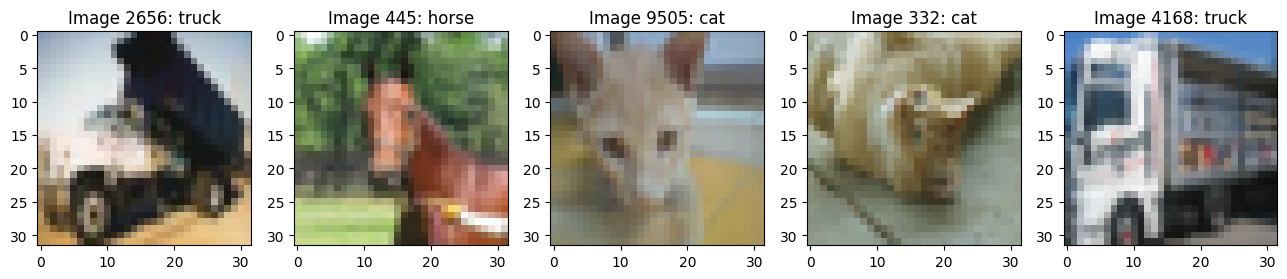

In [17]:
np.random.seed(123)

random_indices = np.random.choice(len(cifar_test), size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(16, 8))

for ax,i in zip(axes, random_indices):
  ax.imshow(torch.permute(cifar_test[i][0], (1,2,0)), cmap="gray")
  ax.set_title(f"Image {i}: {idx_to_class[cifar_test[i][1]]}")

plt.show()

In [18]:
samples = torch.stack([cifar_test[i][0] for i in random_indices], dim=0)
labels = torch.stack([torch.tensor(cifar_test[i][1]) for i in random_indices], dim=0)

## Model (Gradient Descent Codebook Update)

In [19]:
class VQ(nn.Module):
  def __init__(self, latent_dim, k): # k = number of discrete vectors or size of codebook
    super().__init__()
    self.k = k
    self.latent_dim = latent_dim
    self.codebook = nn.Parameter(torch.zeros(k, latent_dim))
    nn.init.trunc_normal_(self.codebook, std=0.02)

  def forward(self, z_e):
    # B, C, H, W = z_e.shape
    ze_permute = torch.permute(z_e, (0, 2, 3, 1)) # (B, H, W, C)
    # calculating distance as ||z-e||2^2 = z^2 + e^2 - 2*z*e.T
    cross = ze_permute @ self.codebook.T # (B, H, W, k)
    z_l2_sq = (ze_permute ** 2).sum(dim=-1, keepdim=True) # (B, H, W, 1)
    e_l2_sq = (self.codebook ** 2).sum(dim=-1) # (k,)

    discrete_codes = torch.argmin((z_l2_sq + e_l2_sq - 2*cross), dim=-1) # (B, H, W)
    z_q = self.codebook[discrete_codes].permute(0, 3, 1, 2) # (B, C, H, W)

    return z_q, discrete_codes

In [20]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 1),
        )

    def forward(self, x):
        return x + self.block(x)

class Encoder(nn.Module):
    def __init__(self, in_channels, hidden, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 4, stride=2, padding=1),
            nn.Conv2d(hidden, hidden, 4, stride=2, padding=1),
            ResidualBlock(hidden),
            ResidualBlock(hidden),
            nn.Conv2d(hidden, latent_dim, 1),  # project to codebook dim
        )

    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(latent_dim, hidden, 1),  # project back from codebook dim
            ResidualBlock(hidden),
            ResidualBlock(hidden),
            nn.ConvTranspose2d(hidden, hidden, 4, stride=2, padding=1),
            nn.ConvTranspose2d(hidden, out_channels, 4, stride=2, padding=1),
        )

    def forward(self, x):
        return self.net(x)

In [21]:
class VQVAE(nn.Module):
  def __init__(self, in_channels, out_channels, latent_dim, hidden, k):
    super().__init__()
    self.encoder = Encoder(in_channels, hidden, latent_dim)
    self.decoder = Decoder(latent_dim, hidden, out_channels)
    self.vq_layer = VQ(latent_dim, k)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    z_e = self.encoder(x)
    z_q, discrete_codes = self.vq_layer(z_e)
    decoder_inp = z_e + (z_q - z_e).detach() # straight through estimator, the effective value for the forward pass is z_q only but the gradients flow to z_e
    reconst = self.sigmoid(self.decoder(decoder_inp))

    return reconst, z_e, z_q, discrete_codes

### Training

In [ ]:
def calc_batch_loss(model, x, device, beta=0.25):
  x = x.to(device)
  reconst, z_e, z_q, discrete_codes = model(x)
  l_1 = nn.functional.binary_cross_entropy(reconst, x, reduction="sum")/x.shape[0]
  # l_1 = nn.functional.binary_cross_entropy(reconst, x)
  ze_permute = torch.permute(z_e, (0, 2, 3, 1)) # (B, H, W, C)
  zq_permute = torch.permute(z_q, (0, 2, 3, 1)) # (B, H, W, C)
  l_2 = (torch.norm(ze_permute.detach() - zq_permute, dim=-1) ** 2).sum()/x.shape[0]
  # l_2 = (torch.norm(ze_permute.detach() - zq_permute, dim=-1) ** 2).mean()
  l_3 = (beta * torch.norm(ze_permute - zq_permute.detach(), dim=-1) ** 2).sum()/x.shape[0]
  # l_3 = (beta * torch.norm(ze_permute - zq_permute.detach(), dim=-1) ** 2).mean()
  loss = l_1 + l_2 + l_3

  return loss, l_1, l_2, l_3, discrete_codes

In [ ]:
def evaluate(loader, model, device, max_batch, k):
  total_loss = 0
  total_l1_loss, total_l2_loss, total_l3_loss = 0, 0, 0
  all_codes = []
  if max_batch is None:
    max_batch = len(loader)
  elif max_batch <= 0:
    return float("nan")
  else:
    max_batch = min(max_batch, len(loader))

  for i, (x, _) in enumerate(loader):
    if i < max_batch:
      with torch.no_grad():
        loss, l_1, l_2, l_3, discrete_codes = calc_batch_loss(model, x, device)
      total_loss += loss.item()
      total_l1_loss += l_1.item()
      total_l2_loss += l_2.item()
      total_l3_loss += l_3.item()
      all_codes.append(discrete_codes.reshape(-1))
    else:
      break
  all_codes = torch.cat(all_codes)

  return total_loss/max_batch, total_l1_loss/max_batch, total_l2_loss/max_batch, total_l3_loss/max_batch, all_codes.unique().numel() / k

In [ ]:
def reconstruct(model, x, device):
    model.eval()
    with torch.no_grad():
      x = x.to(device)
      reconst, _, _, _ = model(x)
    return reconst.cpu()

In [22]:
train_loader1 = DataLoader(cifar_train, batch_size=64, shuffle=True, num_workers=0)
test_loader1 = DataLoader(cifar_test, batch_size=64, shuffle=False, num_workers=0)

In [23]:
len(train_loader1), len(test_loader1)

(782, 157)

#### Exp: 1

In [ ]:
torch.manual_seed(123)
model1 = VQVAE(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512)
model1.to(device)

optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.0001)
epochs = 20
total_steps = epochs * len(train_loader1)
print(f"Total steps: {total_steps}")

global_step1 = -1
train_losses1, val_losses1 = [], []
train_l1_losses1, val_l1_losses1 = [], []
train_l2_losses1, val_l2_losses1 = [], []
train_l3_losses1, val_l3_losses1 = [], []
train_codebook_usage1, val_codebook_usage1 = [], []

t1 = time.time()

model1.train()
for epoch in range(epochs):
    for x, _ in train_loader1:
        optimizer1.zero_grad()
        loss, _, _, _, _ = calc_batch_loss(model1, x, device)
        loss.backward()
        optimizer1.step()
        global_step1 += 1

        if global_step1 % 500 == 0:
            elapsed = time.time() - t1
            steps_done = global_step1 + 1 # coz we are considering 1 to total_steps and not 0 to total_steps-1
            steps_left = total_steps - steps_done
            time_per_step = elapsed / steps_done
            eta_seconds = steps_left * time_per_step
            eta_minutes = eta_seconds / 60
            model1.eval()
            train_loss, train_l1, train_l2, train_l3, train_cu = evaluate(train_loader1, model1, device, max_batch=20, k=512)
            val_loss, val_l1, val_l2, val_l3, val_cu = evaluate(test_loader1, model1, device, max_batch=None, k=512)

            print(f"Epoch: {epoch:3d} \t\t Step: {global_step1:5d}")
            print(f"\t\t\tTrain Loss: {train_loss:.4f} (l1={train_l1:.4f}, l2={train_l2:.4f}, l3={train_l3:.4f}) codebook: {train_cu:.1f}")
            print(f"\t\t\tVal   Loss: {val_loss:.4f} (l1={val_l1:.4f}, l2={val_l2:.4f}, l3={val_l3:.4f}) codebook: {val_cu:.1f}")
            print(f"\t\t\tETA: {eta_minutes:.2f} minutes")

            train_losses1.append(train_loss)
            val_losses1.append(val_loss)
            train_l1_losses1.append(train_l1)
            val_l1_losses1.append(val_l1)
            train_l2_losses1.append(train_l2)
            val_l2_losses1.append(val_l2)
            train_l3_losses1.append(train_l3)
            val_l3_losses1.append(val_l3)
            train_codebook_usage1.append(train_cu)
            val_codebook_usage1.append(val_cu)

            reconst = reconstruct(model1, samples, device)
            fig, axes = plt.subplots(2, 5, figsize=(16, 6))
            for i in range(5):
                axes[0, i].imshow(torch.permute(samples[i], (1, 2, 0)))
                axes[0, i].set_title(f"original {labels[i]}")
                axes[0, i].axis("off")
                axes[1, i].imshow(torch.permute(reconst[i], (1, 2, 0)))
                axes[1, i].set_title(f"reconst {labels[i]}")
                axes[1, i].axis("off")
            plt.tight_layout()
            plt.show()
            model1.train()

t2 = time.time()
print(f"Total training time: {t2-t1:.1f}s")

In [ ]:
torch.save(model1.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae_exp1.pt")

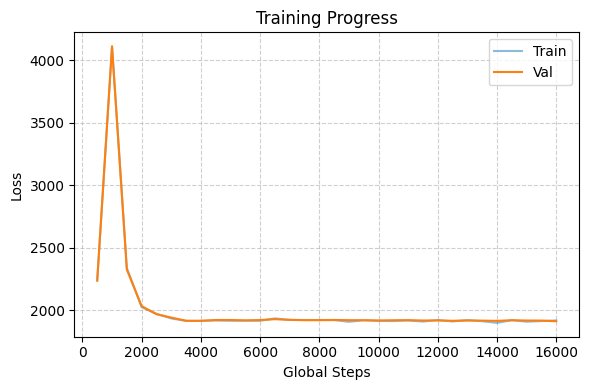

In [ ]:
plot_training_results(train_losses1, val_losses1, 500, title="Training Progress", y_title="Loss")

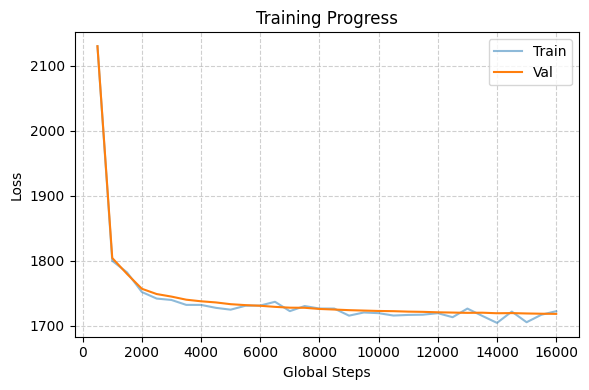

In [ ]:
plot_training_results(train_l1_losses1, val_l1_losses1, 500, title="Training Progress", y_title="Loss")

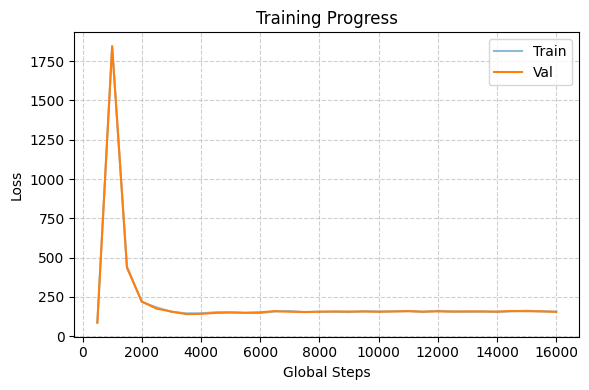

In [ ]:
plot_training_results(train_l2_losses1, val_l2_losses1, 500, title="Training Progress", y_title="Loss")

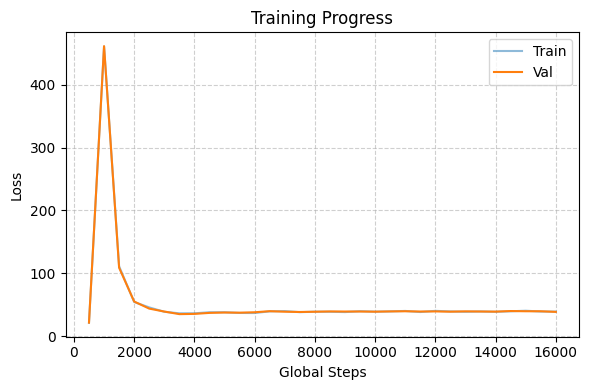

In [ ]:
plot_training_results(train_l3_losses1, val_l3_losses1, 500, title="Training Progress", y_title="Loss")

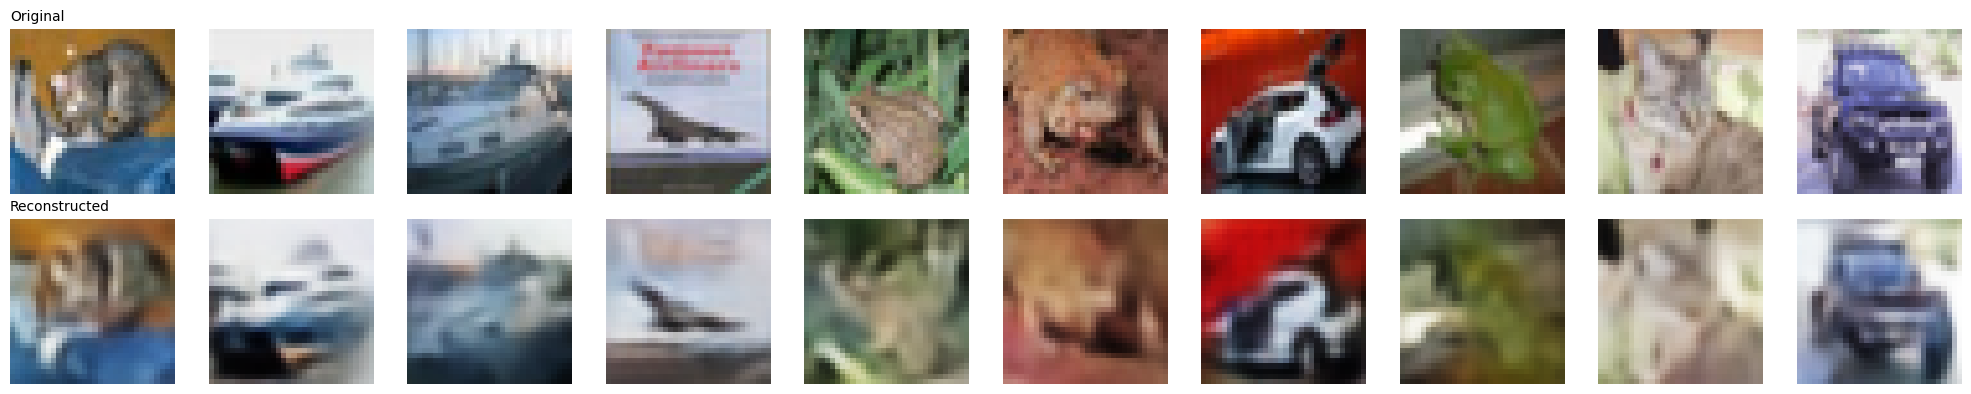

In [ ]:
model = VQVAE(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_exp1.pt"))
model.to(device)

plot_generated_vs_original(model, test_loader1, device=device)

In [28]:
model = VQVAE(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_exp1.pt"))
model.to(device)

model.eval()
lpips_score = evaluate_lpips(model, test_loader1, device)
rfid_score  = evaluate_rfid(model, test_loader1, device, n_images=5000)

gen_eval["exp_1"] = (lpips_score, rfid_score)

print(f"LPIPS: {lpips_score:.4f}")
print(f"rFID:  {rfid_score:.2f}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


compute FID between two folders
Found 5000 images in the folder /tmp/rfid_eval/real


FID real :   0%|          | 0/157 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
FID real : 100%|██████████| 157/157 [00:31<00:00,  5.03it/s]


Found 5000 images in the folder /tmp/rfid_eval/recon


FID recon : 100%|██████████| 157/157 [00:31<00:00,  4.97it/s]


LPIPS: 0.0545
rFID:  79.00


#### Exp: 2

Increasing the latent_dim to 512 from 256

In [ ]:
torch.manual_seed(123)
model2 = VQVAE(in_channels=3, out_channels=3, latent_dim=512, hidden=256, k=512)
model2.to(device)

optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.0001)
epochs = 20
total_steps = epochs * len(train_loader1)
print(f"Total steps: {total_steps}")

global_step2 = -1
train_losses2, val_losses2 = [], []
train_l1_losses2, val_l1_losses2 = [], []
train_l2_losses2, val_l2_losses2 = [], []
train_l3_losses2, val_l3_losses2 = [], []
train_codebook_usage2, val_codebook_usage2 = [], []

t3 = time.time()

model2.train()
for epoch in range(epochs):
    for x, _ in train_loader1:
        optimizer2.zero_grad()
        loss, _, _, _, _ = calc_batch_loss(model2, x, device)
        loss.backward()
        optimizer2.step()
        global_step2 += 1
        if global_step2 % 500 == 0:
            elapsed = time.time() - t3
            steps_done = global_step2 + 1
            steps_left = total_steps - steps_done
            time_per_step = elapsed / steps_done
            eta_seconds = steps_left * time_per_step
            eta_minutes = eta_seconds / 60
            model2.eval()
            train_loss, train_l1, train_l2, train_l3, train_cu = evaluate(train_loader1, model2, device, max_batch=20, k=512)
            val_loss, val_l1, val_l2, val_l3, val_cu = evaluate(test_loader1, model2, device, max_batch=None, k=512)
            print(f"Epoch: {epoch:3d} \t\t Step: {global_step2:5d}")
            print(f"\t\t\tTrain Loss: {train_loss:.4f} (l1={train_l1:.4f}, l2={train_l2:.4f}, l3={train_l3:.4f}) codebook: {train_cu:.1f}")
            print(f"\t\t\tVal   Loss: {val_loss:.4f} (l1={val_l1:.4f}, l2={val_l2:.4f}, l3={val_l3:.4f}) codebook: {val_cu:.1f}")
            print(f"\t\t\tETA: {eta_minutes:.2f} minutes")
            train_losses2.append(train_loss)
            val_losses2.append(val_loss)
            train_l1_losses2.append(train_l1)
            val_l1_losses2.append(val_l1)
            train_l2_losses2.append(train_l2)
            val_l2_losses2.append(val_l2)
            train_l3_losses2.append(train_l3)
            val_l3_losses2.append(val_l3)
            train_codebook_usage2.append(train_cu)
            val_codebook_usage2.append(val_cu)
            reconst = reconstruct(model2, samples, device)
            fig, axes = plt.subplots(2, 5, figsize=(16, 6))
            for i in range(5):
                axes[0, i].imshow(torch.permute(samples[i], (1, 2, 0)))
                axes[0, i].set_title(f"original {labels[i]}")
                axes[0, i].axis("off")
                axes[1, i].imshow(torch.permute(reconst[i], (1, 2, 0)))
                axes[1, i].set_title(f"reconst {labels[i]}")
                axes[1, i].axis("off")
            plt.tight_layout()
            plt.show()
            model2.train()

t4 = time.time()
print(f"Total training time: {t4-t3:.1f}s")

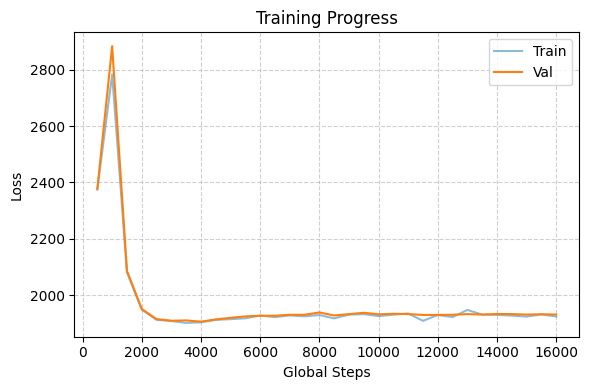

In [ ]:
plot_training_results(train_losses2, val_losses2, 500, title="Training Progress", y_title="Loss")

In [ ]:
torch.save(model2.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae_exp2.pt")

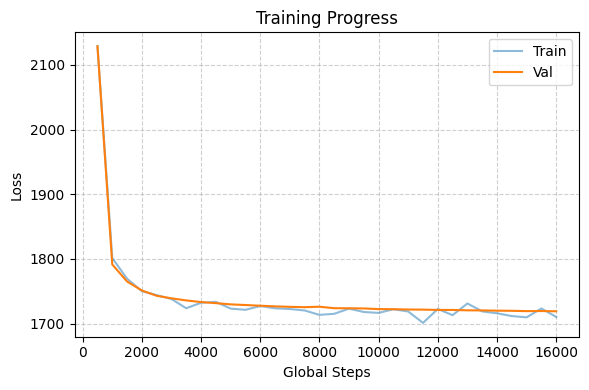

In [ ]:
plot_training_results(train_l1_losses2, val_l1_losses2, 500, title="Training Progress", y_title="Loss")

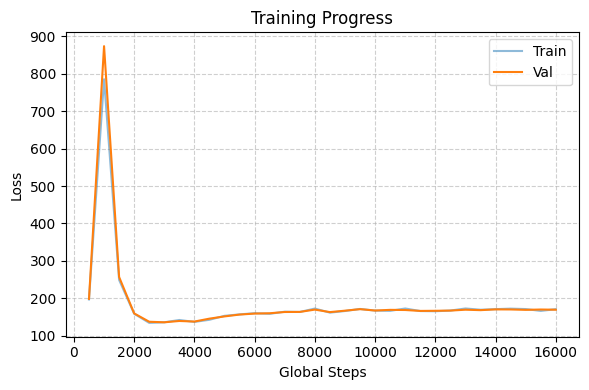

In [ ]:
plot_training_results(train_l2_losses2, val_l2_losses2, 500, title="Training Progress", y_title="Loss")

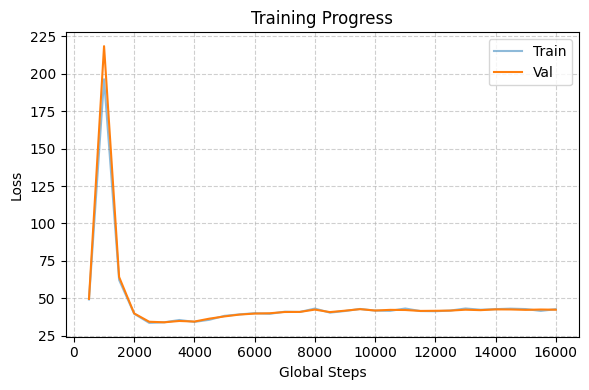

In [ ]:
plot_training_results(train_l3_losses2, val_l3_losses2, 500, title="Training Progress", y_title="Loss")

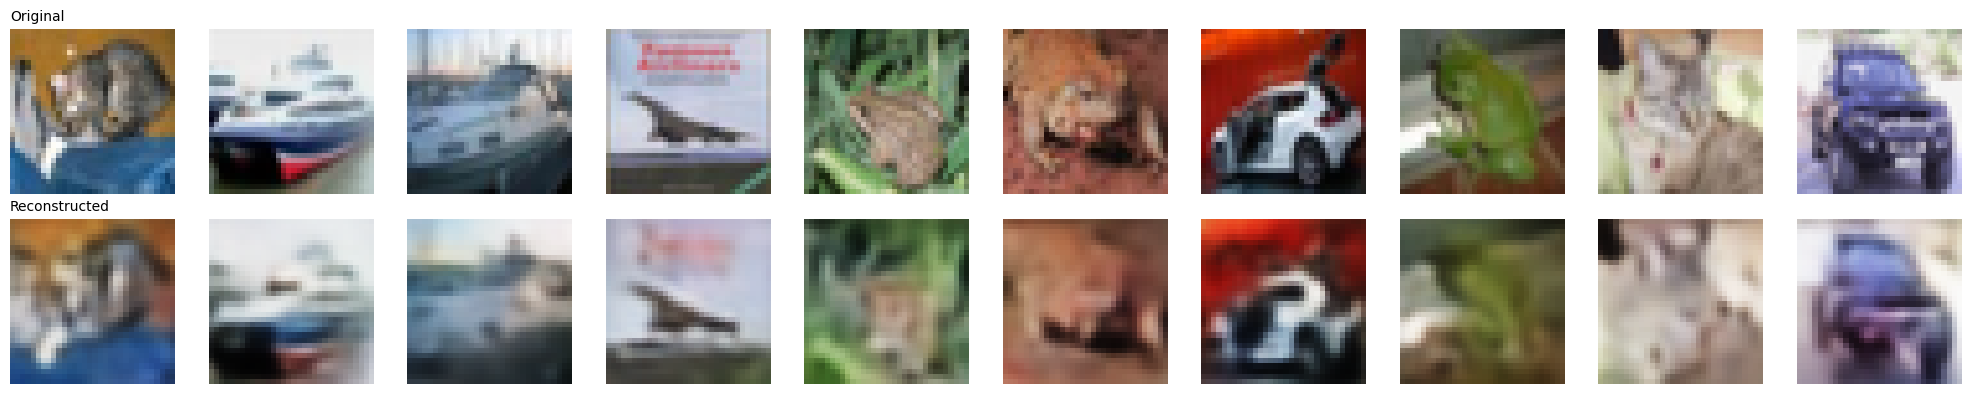

In [ ]:
model = VQVAE(in_channels=3, out_channels=3, latent_dim=512, hidden=256, k=512)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_exp2.pt"))
model.to(device)

plot_generated_vs_original(model, test_loader1, device=device)

In [29]:
model = VQVAE(in_channels=3, out_channels=3, latent_dim=512, hidden=256, k=512)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_exp2.pt"))
model.to(device)

model.eval()
lpips_score = evaluate_lpips(model, test_loader1, device)
rfid_score  = evaluate_rfid(model, test_loader1, device, n_images=5000)

gen_eval["exp_2"] = (lpips_score, rfid_score)

print(f"LPIPS: {lpips_score:.4f}")
print(f"rFID:  {rfid_score:.2f}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
compute FID between two folders
Found 5000 images in the folder /tmp/rfid_eval/real


FID real : 100%|██████████| 157/157 [00:42<00:00,  3.74it/s]


Found 5000 images in the folder /tmp/rfid_eval/recon


FID recon : 100%|██████████| 157/157 [00:36<00:00,  4.33it/s]


LPIPS: 0.0634
rFID:  79.20


Based on exp2, it can be said that latent_dim is not the cause of blurry images generation.

Upon looking at codebook utilization in both experiments: 1 and 2, the lower utilization seems to be a problem. Can try EMA codebook updates.

#### Exp: 3

With minibatches, the code book update depends on which discrete latents were utilized in previous steps and the one which were utilized are improved and the others remain same, and since the utilized discrete latents were impoved they are again utilized and further gets improved. Rich gets richer problem.

Experiment with larger minibatches.

In [30]:
train_loader2 = DataLoader(cifar_train, batch_size=1024, shuffle=True, num_workers=0)
test_loader2 = DataLoader(cifar_test, batch_size=1024, shuffle=False, num_workers=0)

In [31]:
len(train_loader2), len(test_loader2)

(49, 10)

In [ ]:
torch.manual_seed(123)
model3 = VQVAE(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512)
model3.to(device)

optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.0001)
epochs = 20
total_steps = epochs * len(train_loader2)
print(f"Total steps: {total_steps}")

global_step3 = -1
train_losses3, val_losses3 = [], []
train_l1_losses3, val_l1_losses3 = [], []
train_l2_losses3, val_l2_losses3 = [], []
train_l3_losses3, val_l3_losses3 = [], []
train_codebook_usage3, val_codebook_usage3 = [], []

t5 = time.time()

model3.train()
for epoch in range(epochs):
    for x, _ in train_loader2:
        optimizer3.zero_grad()
        loss, _, _, _, _ = calc_batch_loss(model3, x, device)
        loss.backward()
        optimizer3.step()
        global_step3 += 1
        if global_step3 % 50 == 0:
            elapsed = time.time() - t5
            steps_done = global_step3 + 1
            steps_left = total_steps - steps_done
            time_per_step = elapsed / steps_done
            eta_seconds = steps_left * time_per_step
            eta_minutes = eta_seconds / 60
            model3.eval()
            train_loss, train_l1, train_l2, train_l3, train_cu = evaluate(train_loader2, model3, device, max_batch=20, k=512)
            val_loss, val_l1, val_l2, val_l3, val_cu = evaluate(test_loader2, model3, device, max_batch=None, k=512)
            print(f"Epoch: {epoch:3d} \t\t Step: {global_step3:5d}")
            print(f"\t\t\tTrain Loss: {train_loss:.4f} (l1={train_l1:.4f}, l2={train_l2:.4f}, l3={train_l3:.4f}) codebook: {train_cu:.1f}")
            print(f"\t\t\tVal   Loss: {val_loss:.4f} (l1={val_l1:.4f}, l2={val_l2:.4f}, l3={val_l3:.4f}) codebook: {val_cu:.1f}")
            print(f"\t\t\tETA: {eta_minutes:.2f} minutes")
            train_losses3.append(train_loss)
            val_losses3.append(val_loss)
            train_l1_losses3.append(train_l1)
            val_l1_losses3.append(val_l1)
            train_l2_losses3.append(train_l2)
            val_l2_losses3.append(val_l2)
            train_l3_losses3.append(train_l3)
            val_l3_losses3.append(val_l3)
            train_codebook_usage3.append(train_cu)
            val_codebook_usage3.append(val_cu)
            reconst = reconstruct(model3, samples, device)
            fig, axes = plt.subplots(2, 5, figsize=(16, 6))
            for i in range(5):
                axes[0, i].imshow(torch.permute(samples[i], (1, 2, 0)))
                axes[0, i].set_title(f"original {labels[i]}")
                axes[0, i].axis("off")
                axes[1, i].imshow(torch.permute(reconst[i], (1, 2, 0)))
                axes[1, i].set_title(f"reconst {labels[i]}")
                axes[1, i].axis("off")
            plt.tight_layout()
            plt.show()
            model3.train()

t6 = time.time()
print(f"Total training time: {t6-t5:.1f}s")

Even with the larger minibatches of size 1024, the codebook utilization is still 0.1. Hence, no improvement with larger minibatches.

In [ ]:
torch.save(model3.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae_exp3.pt")

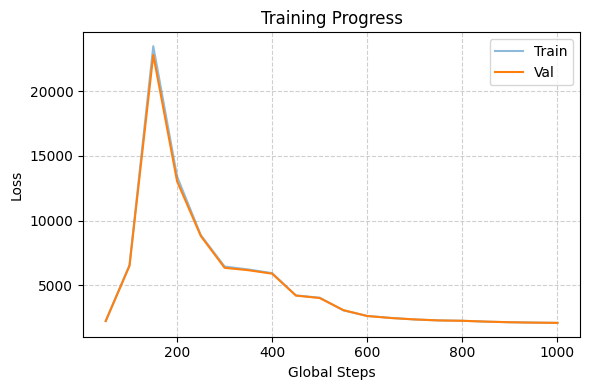

In [ ]:
plot_training_results(train_losses3, val_losses3, 50, title="Training Progress", y_title="Loss")

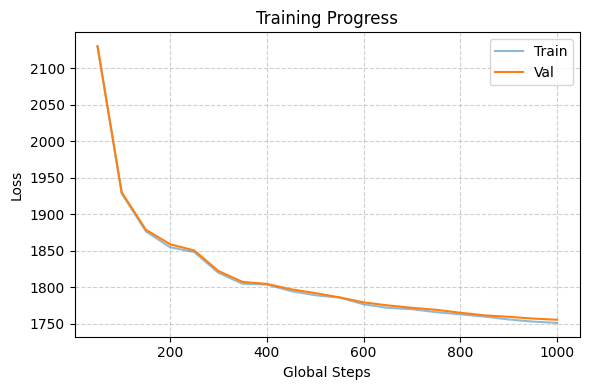

In [ ]:
plot_training_results(train_l1_losses3, val_l1_losses3, 50, title="Training Progress", y_title="Loss")

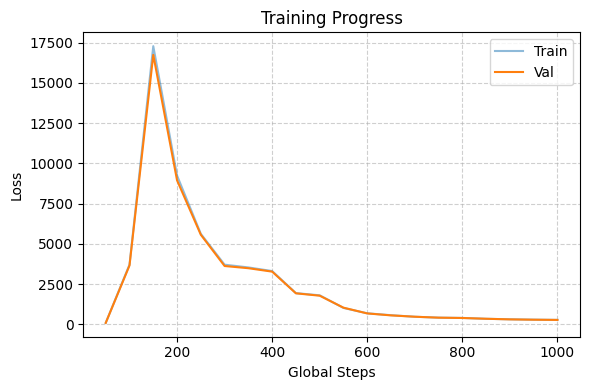

In [ ]:
plot_training_results(train_l2_losses3, val_l2_losses3, 50, title="Training Progress", y_title="Loss")

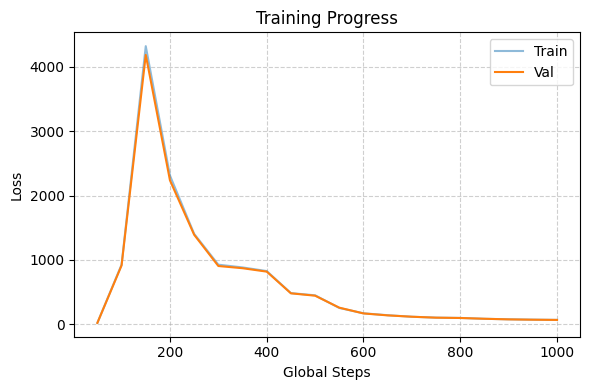

In [ ]:
plot_training_results(train_l3_losses3, val_l3_losses3, 50, title="Training Progress", y_title="Loss")

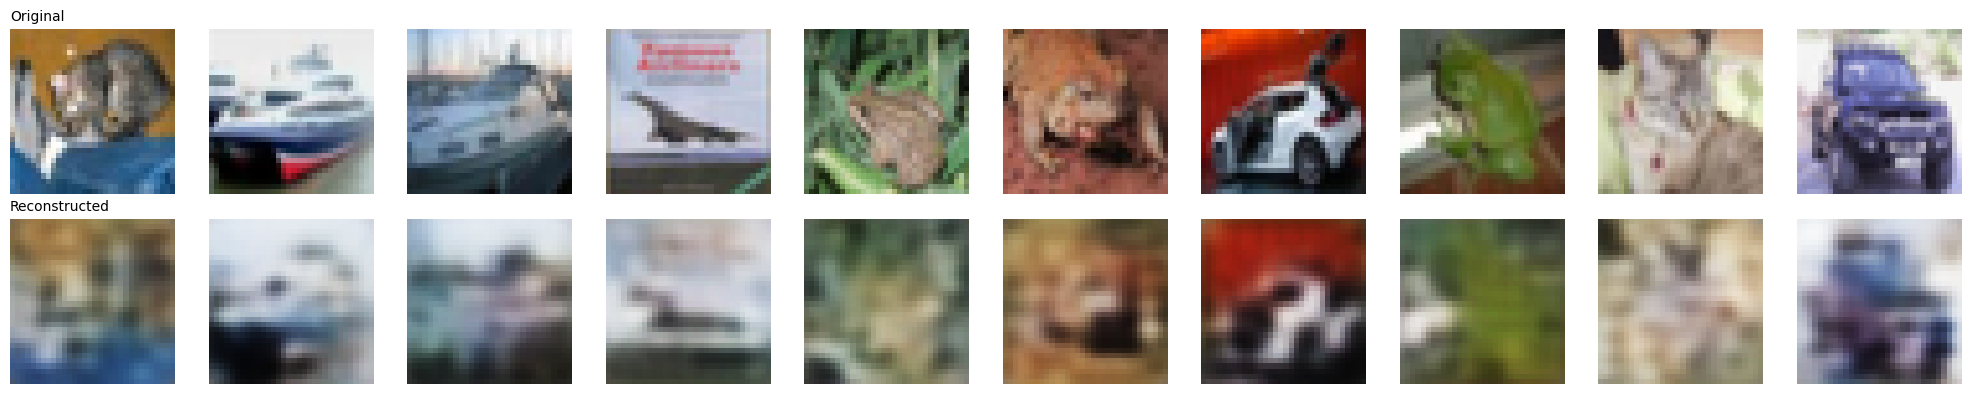

In [ ]:
model = VQVAE(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_exp3.pt"))
model.to(device)

plot_generated_vs_original(model, test_loader2, device=device)

In [32]:
model = VQVAE(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_exp3.pt"))
model.to(device)

model.eval()
lpips_score = evaluate_lpips(model, test_loader2, device)
rfid_score  = evaluate_rfid(model, test_loader2, device, n_images=5000)

gen_eval["exp_3"] = (lpips_score, rfid_score)

print(f"LPIPS: {lpips_score:.4f}")
print(f"rFID:  {rfid_score:.2f}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


compute FID between two folders
Found 5000 images in the folder /tmp/rfid_eval/real


FID real :   0%|          | 0/157 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
FID real : 100%|██████████| 157/157 [00:33<00:00,  4.66it/s]


Found 5000 images in the folder /tmp/rfid_eval/recon


FID recon : 100%|██████████| 157/157 [00:35<00:00,  4.46it/s]


LPIPS: 0.1739
rFID:  119.78


## Model (EMA Codebook Update)

In [33]:
class VQ2(nn.Module):
  def __init__(self, latent_dim, k, decay=0.99): # k = number of discrete vectors or size of codebook
    super().__init__()
    self.k = k
    self.latent_dim = latent_dim
    self.register_buffer("moving_sum", torch.zeros(k, latent_dim))
    self.register_buffer("moving_count", torch.zeros(k))
    self.register_buffer("codebook", torch.zeros(k, latent_dim))
    self.register_buffer("initialized", torch.tensor(False))
    self.register_buffer("decay", torch.tensor(decay))

  def forward(self, z_e, training):
    B, C, H, W = z_e.shape
    ze_permute = torch.permute(z_e, (0, 2, 3, 1)) # (B, H, W, C)
    if not self.initialized:
      ze_flatten = ze_permute.reshape(-1, C)
      if ze_flatten.shape[0] < self.k:
        indices = torch.randint(0, ze_flatten.shape[0], (self.k,))
        self.codebook.data.copy_(ze_flatten[indices])
        self.initialized.fill_(True)
      else:
        indices = torch.randperm(ze_flatten.shape[0])[:self.k]
        self.codebook.data.copy_(ze_flatten[indices])
        self.initialized.fill_(True)

    # calculating distance as ||z-e||2^2 = z^2 + e^2 - 2*z*e.T
    cross = ze_permute @ self.codebook.T # (B, H, W, k)
    z_l2_sq = (ze_permute ** 2).sum(dim=-1, keepdim=True) # (B, H, W, 1)
    e_l2_sq = (self.codebook ** 2).sum(dim=-1) # (k,)

    discrete_codes = torch.argmin((z_l2_sq + e_l2_sq - 2*cross), dim=-1) # (B, H, W)
    z_q = self.codebook[discrete_codes].permute(0, 3, 1, 2) # (B, C, H, W)

    # EMA codebook update
    if training:
      n_t = torch.zeros(self.k, device=z_e.device)
      codes_flatten = discrete_codes.reshape(-1)
      n_t.scatter_add_(0, codes_flatten, torch.ones(codes_flatten.shape, device=z_e.device)) # current code-wise utilization count
      self.moving_count.copy_(self.moving_count * self.decay + n_t * (1 - self.decay))
      ze_flatten = ze_permute.reshape(-1, C)
      current_code_sum = torch.zeros_like(self.moving_sum)
      # for i in range(self.k):
      #   assigned_indices = torch.where(codes_flatten == i)[0]
      #   if assigned_indices.shape[0] > 0:
      #     assigned_ze = ze_flatten[assigned_indices]
      #     m_i = assigned_ze.sum(0)
      #     current_code_sum[i] = m_i
      current_code_sum.scatter_add_(0, codes_flatten.unsqueeze(-1).expand(-1, C), ze_flatten)
      self.moving_sum.copy_(self.moving_sum * self.decay + current_code_sum * (1 - self.decay))
      safe_count = self.moving_count.unsqueeze(-1).clamp(min=1e-6)
      self.codebook.data.copy_(self.moving_sum / safe_count)

    return z_q, discrete_codes

In [34]:
class ResidualBlock2(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 1),
        )

    def forward(self, x):
        return x + self.block(x)

class Encoder2(nn.Module):
    def __init__(self, in_channels, hidden, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 4, stride=2, padding=1),
            nn.Conv2d(hidden, hidden, 4, stride=2, padding=1),
            ResidualBlock2(hidden),
            ResidualBlock2(hidden),
            nn.Conv2d(hidden, latent_dim, 1),  # project to codebook dim
        )

    def forward(self, x):
        return self.net(x)

class Decoder2(nn.Module):
    def __init__(self, latent_dim, hidden, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(latent_dim, hidden, 1),  # project back from codebook dim
            ResidualBlock2(hidden),
            ResidualBlock2(hidden),
            nn.ConvTranspose2d(hidden, hidden, 4, stride=2, padding=1),
            nn.ConvTranspose2d(hidden, out_channels, 4, stride=2, padding=1),
        )

    def forward(self, x):
        return self.net(x)

In [35]:
class VQVAE2(nn.Module):
  def __init__(self, in_channels, out_channels, latent_dim, hidden, k, decay=0.99):
    super().__init__()
    self.encoder = Encoder2(in_channels, hidden, latent_dim)
    self.decoder = Decoder2(latent_dim, hidden, out_channels)
    self.vq_layer = VQ2(latent_dim, k, decay=decay)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x, training=False):
    z_e = self.encoder(x)
    z_q, discrete_codes = self.vq_layer(z_e, training)
    decoder_inp = z_e + (z_q - z_e).detach() # straight through estimator, the effective value for the forward pass is z_q only but the gradients flow to z_e
    reconst = self.sigmoid(self.decoder(decoder_inp))

    return reconst, z_e, z_q, discrete_codes

### Training

In [ ]:
def calc_batch_loss2(model, x, device, training, beta=0.25):
  x = x.to(device)
  reconst, z_e, z_q, discrete_codes = model(x, training)
  # l_1 = nn.functional.binary_cross_entropy(reconst, x, reduction="sum")/x.shape[0]
  l_1 = nn.functional.binary_cross_entropy(reconst, x)
  ze_permute = torch.permute(z_e, (0, 2, 3, 1)) # (B, H, W, C)
  zq_permute = torch.permute(z_q, (0, 2, 3, 1)) # (B, H, W, C)
  # l_3 = (beta * torch.norm(ze_permute - zq_permute.detach(), dim=-1) ** 2).sum()/x.shape[0]
  l_3 = (beta * torch.norm(ze_permute - zq_permute.detach(), dim=-1) ** 2).mean()
  loss = l_1 + l_3

  return loss, l_1, l_3, discrete_codes

In [ ]:
def evaluate2(loader, model, device, max_batch, k):
  total_loss = 0
  total_l1_loss, total_l3_loss = 0, 0
  all_codes = []
  if max_batch is None:
    max_batch = len(loader)
  elif max_batch <= 0:
    return float("nan")
  else:
    max_batch = min(max_batch, len(loader))

  for i, (x, _) in enumerate(loader):
    if i < max_batch:
      with torch.no_grad():
        loss, l_1, l_3, discrete_codes = calc_batch_loss2(model, x, device, training=False)
      total_loss += loss.item()
      total_l1_loss += l_1.item()
      total_l3_loss += l_3.item()
      all_codes.append(discrete_codes.reshape(-1))
    else:
      break
  all_codes = torch.cat(all_codes)

  return total_loss/max_batch, total_l1_loss/max_batch, total_l3_loss/max_batch, all_codes.unique().numel() / k

In [ ]:
def reconstruct2(model, x, device):
    model.eval()
    with torch.no_grad():
      x = x.to(device)
      reconst, _, _, _ = model(x, training=False)
    return reconst.cpu()

In [36]:
train_loader3 = DataLoader(cifar_train, batch_size=64, shuffle=True, num_workers=0)
test_loader3 = DataLoader(cifar_test, batch_size=64, shuffle=False, num_workers=0)

In [37]:
len(train_loader3), len(test_loader3)

(782, 157)

#### Exp: 4

Using EMA codebook update instead of gradient descent based update. EMA is more stable since it directly updates the latent embeddings to what it should be.

In [ ]:
torch.manual_seed(123)
model4 = VQVAE2(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512)
model4.to(device)

optimizer4 = torch.optim.Adam(model4.parameters(), lr=0.0001)
epochs = 20
total_steps = epochs * len(train_loader3)
print(f"Total steps: {total_steps}")

global_step4 = -1
train_losses4, val_losses4 = [], []
train_l1_losses4, val_l1_losses4 = [], []
train_l3_losses4, val_l3_losses4 = [], []
train_codebook_usage4, val_codebook_usage4 = [], []

t7 = time.time()

model4.train()
for epoch in range(epochs):
    for x, _ in train_loader3:
        optimizer4.zero_grad()
        loss, _, _, _ = calc_batch_loss2(model4, x, device, training=True)
        loss.backward()
        optimizer4.step()
        global_step4 += 1
        if global_step4 % 500 == 0:
            elapsed = time.time() - t7
            steps_done = global_step4 + 1
            steps_left = total_steps - steps_done
            time_per_step = elapsed / steps_done
            eta_seconds = steps_left * time_per_step
            eta_minutes = eta_seconds / 60
            model4.eval()
            train_loss, train_l1, train_l3, train_cu = evaluate2(train_loader3, model4, device, max_batch=20, k=512)
            val_loss, val_l1, val_l3, val_cu = evaluate2(test_loader3, model4, device, max_batch=None, k=512)
            print(f"Epoch: {epoch:3d} \t\t Step: {global_step4:5d}")
            print(f"\t\t\tTrain Loss: {train_loss:.4f} (l1={train_l1:.4f}, l3={train_l3:.4f}) codebook: {train_cu:.1f}")
            print(f"\t\t\tVal   Loss: {val_loss:.4f} (l1={val_l1:.4f}, l3={val_l3:.4f}) codebook: {val_cu:.1f}")
            print(f"\t\t\tETA: {eta_minutes:.2f} minutes")
            train_losses4.append(train_loss)
            val_losses4.append(val_loss)
            train_l1_losses4.append(train_l1)
            val_l1_losses4.append(val_l1)
            train_l3_losses4.append(train_l3)
            val_l3_losses4.append(val_l3)
            train_codebook_usage4.append(train_cu)
            val_codebook_usage4.append(val_cu)
            reconst = reconstruct2(model4, samples, device)
            fig, axes = plt.subplots(2, 5, figsize=(16, 6))
            for i in range(5):
                axes[0, i].imshow(torch.permute(samples[i], (1, 2, 0)))
                axes[0, i].set_title(f"original {labels[i]}")
                axes[0, i].axis("off")
                axes[1, i].imshow(torch.permute(reconst[i], (1, 2, 0)))
                axes[1, i].set_title(f"reconst {labels[i]}")
                axes[1, i].axis("off")
            plt.tight_layout()
            plt.show()
            model4.train()

t8 = time.time()
print(f"Total training time: {t8-t7:.1f}s")

In [ ]:
torch.save(model4.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae_exp4.pt")

The codebook utilization seems to have been improved slightly to 0.2, but still it is very low and causing the model to stop learning.

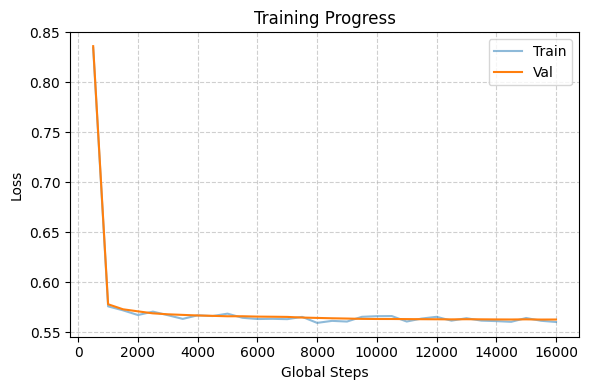

In [ ]:
plot_training_results(train_losses4, val_losses4, 500, title="Training Progress", y_title="Loss")

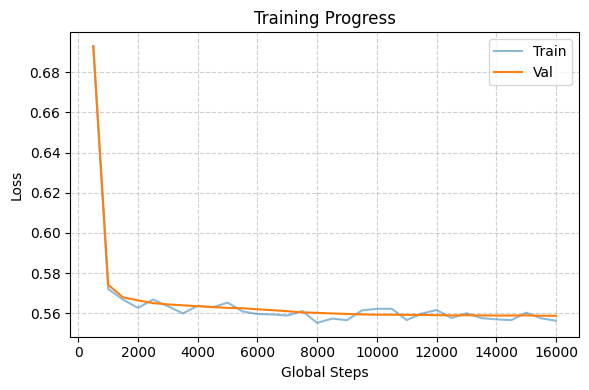

In [ ]:
plot_training_results(train_l1_losses4, val_l1_losses4, 500, title="Training Progress", y_title="Loss")

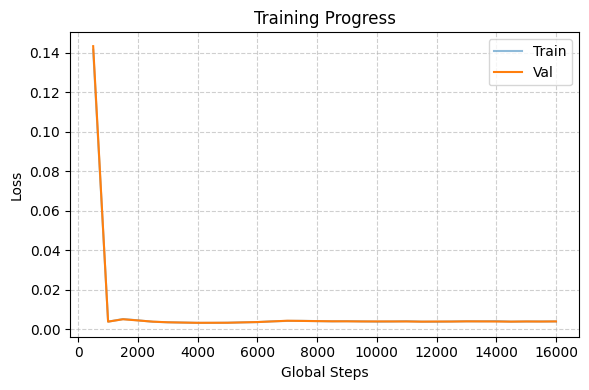

In [ ]:
plot_training_results(train_l3_losses4, val_l3_losses4, 500, title="Training Progress", y_title="Loss")

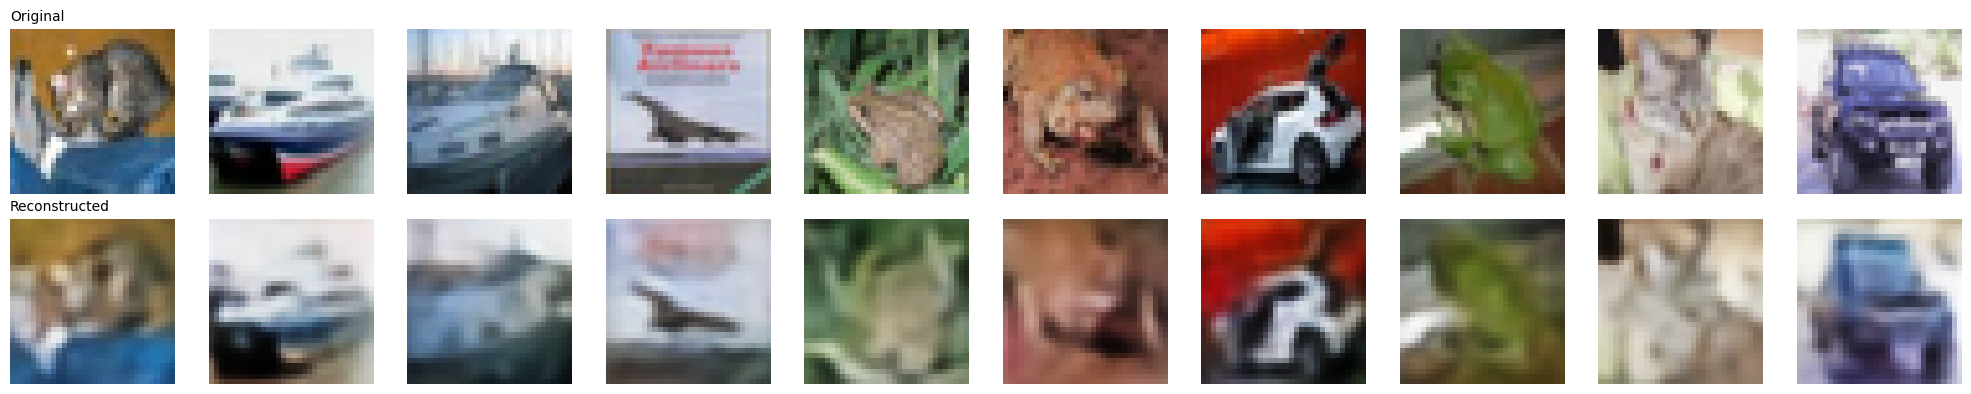

In [ ]:
model = VQVAE2(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_exp4.pt"))
model.to(device)

plot_generated_vs_original(model, test_loader3, device=device)

In [38]:
model = VQVAE2(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_exp4.pt"))
model.to(device)

model.eval()
lpips_score = evaluate_lpips(model, test_loader3, device)
rfid_score  = evaluate_rfid(model, test_loader3, device, n_images=5000)

gen_eval["exp_4"] = (lpips_score, rfid_score)

print(f"LPIPS: {lpips_score:.4f}")
print(f"rFID:  {rfid_score:.2f}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
compute FID between two folders
Found 5000 images in the folder /tmp/rfid_eval/real


FID real : 100%|██████████| 157/157 [00:33<00:00,  4.70it/s]


Found 5000 images in the folder /tmp/rfid_eval/recon


FID recon : 100%|██████████| 157/157 [00:33<00:00,  4.64it/s]


LPIPS: 0.0746
rFID:  84.94


#### Exp: 5

Decreasing decay from 0.99 to 0.80 so that codebook gives slightly more weight to current batch's encoder sum and discrete code count, which further can update codebook towards encoder outputs faster.

In [ ]:
torch.manual_seed(123)
model5 = VQVAE2(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512, decay=0.8)
model5.to(device)

optimizer5 = torch.optim.Adam(model5.parameters(), lr=0.0001)
epochs = 20
total_steps = epochs * len(train_loader3)
print(f"Total steps: {total_steps}")

global_step5 = -1
train_losses5, val_losses5 = [], []
train_l1_losses5, val_l1_losses5 = [], []
train_l3_losses5, val_l3_losses5 = [], []
train_codebook_usage5, val_codebook_usage5 = [], []

t9 = time.time()

model5.train()
for epoch in range(epochs):
    for x, _ in train_loader3:
        optimizer5.zero_grad()
        loss, _, _, _ = calc_batch_loss2(model5, x, device, training=True)
        loss.backward()
        optimizer5.step()
        global_step5 += 1
        if global_step5 % 500 == 0:
            elapsed = time.time() - t9
            steps_done = global_step5 + 1
            steps_left = total_steps - steps_done
            time_per_step = elapsed / steps_done
            eta_seconds = steps_left * time_per_step
            eta_minutes = eta_seconds / 60
            model5.eval()
            train_loss, train_l1, train_l3, train_cu = evaluate2(train_loader3, model5, device, max_batch=20, k=512)
            val_loss, val_l1, val_l3, val_cu = evaluate2(test_loader3, model5, device, max_batch=None, k=512)
            print(f"Epoch: {epoch:3d} \t\t Step: {global_step5:5d}")
            print(f"\t\t\tTrain Loss: {train_loss:.4f} (l1={train_l1:.4f}, l3={train_l3:.4f}) codebook: {train_cu:.1f}")
            print(f"\t\t\tVal   Loss: {val_loss:.4f} (l1={val_l1:.4f}, l3={val_l3:.4f}) codebook: {val_cu:.1f}")
            print(f"\t\t\tETA: {eta_minutes:.2f} minutes")
            train_losses5.append(train_loss)
            val_losses5.append(val_loss)
            train_l1_losses5.append(train_l1)
            val_l1_losses5.append(val_l1)
            train_l3_losses5.append(train_l3)
            val_l3_losses5.append(val_l3)
            train_codebook_usage5.append(train_cu)
            val_codebook_usage5.append(val_cu)
            reconst = reconstruct2(model5, samples, device)
            fig, axes = plt.subplots(2, 5, figsize=(16, 6))
            for i in range(5):
                axes[0, i].imshow(torch.permute(samples[i], (1, 2, 0)))
                axes[0, i].set_title(f"original {labels[i]}")
                axes[0, i].axis("off")
                axes[1, i].imshow(torch.permute(reconst[i], (1, 2, 0)))
                axes[1, i].set_title(f"reconst {labels[i]}")
                axes[1, i].axis("off")
            plt.tight_layout()
            plt.show()
            model5.train()

t10 = time.time()
print(f"Total training time: {t10-t9:.1f}s")

In [ ]:
torch.save(model5.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae_exp5.pt")

No improvement.

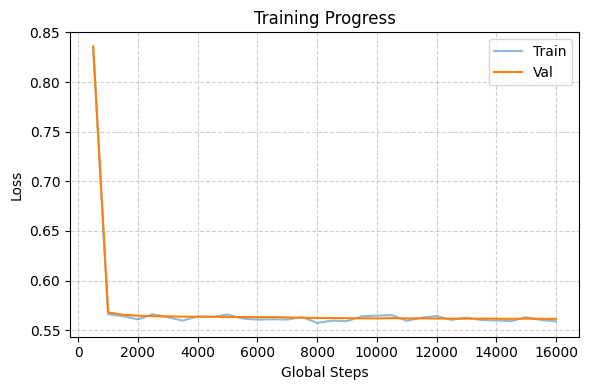

In [ ]:
plot_training_results(train_losses5, val_losses5, 500, title="Training Progress", y_title="Loss")

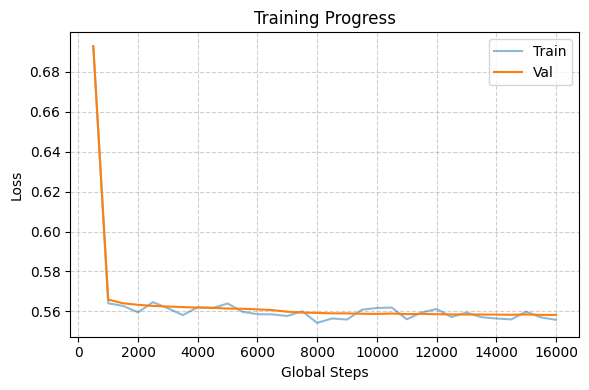

In [ ]:
plot_training_results(train_l1_losses5, val_l1_losses5, 500, title="Training Progress", y_title="Loss")

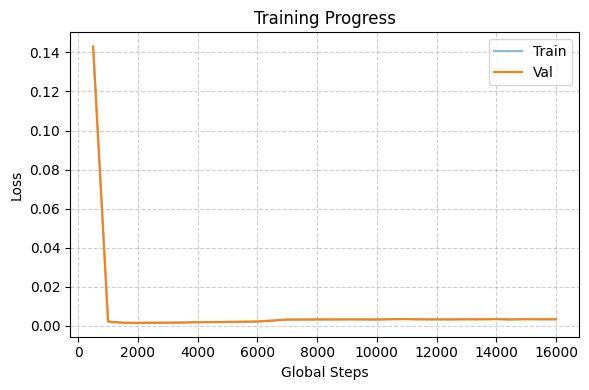

In [ ]:
plot_training_results(train_l3_losses5, val_l3_losses5, 500, title="Training Progress", y_title="Loss")

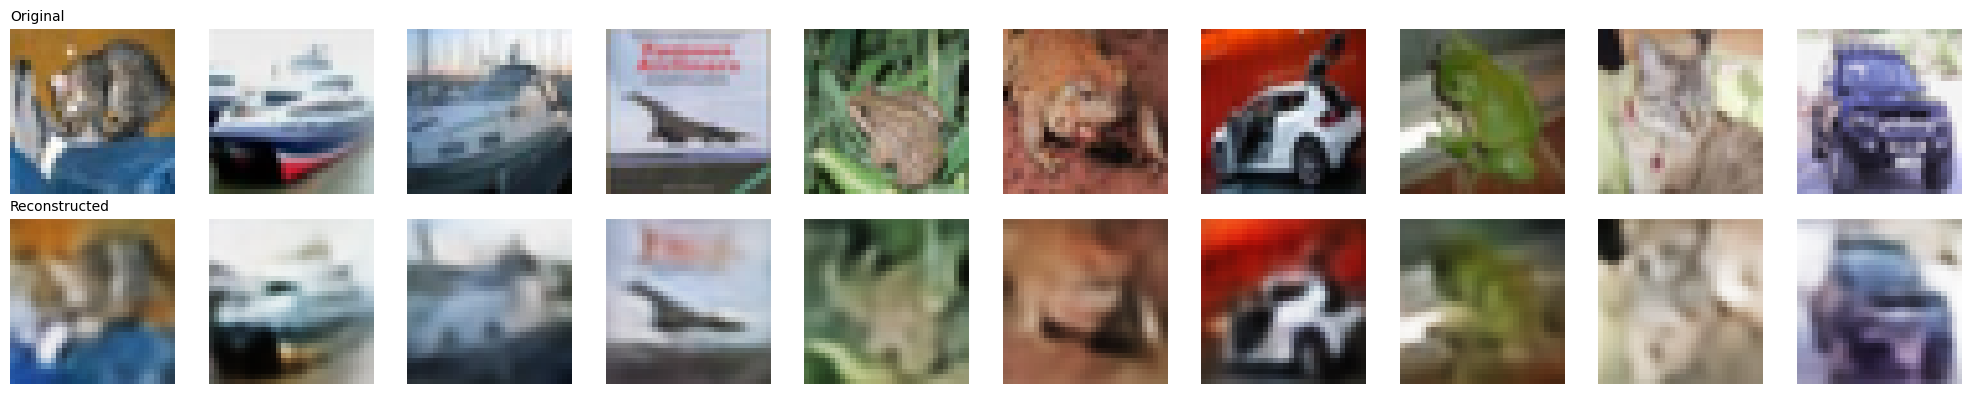

In [ ]:
model = VQVAE2(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512, decay=0.8)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_exp5.pt"))
model.to(device)

plot_generated_vs_original(model, test_loader3, device=device)

In [39]:
model = VQVAE2(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512, decay=0.8)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_exp5.pt"))
model.to(device)

model.eval()
lpips_score = evaluate_lpips(model, test_loader3, device)
rfid_score  = evaluate_rfid(model, test_loader3, device, n_images=5000)

gen_eval["exp_5"] = (lpips_score, rfid_score)

print(f"LPIPS: {lpips_score:.4f}")
print(f"rFID:  {rfid_score:.2f}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
compute FID between two folders
Found 5000 images in the folder /tmp/rfid_eval/real


FID real : 100%|██████████| 157/157 [00:33<00:00,  4.62it/s]


Found 5000 images in the folder /tmp/rfid_eval/recon


FID recon : 100%|██████████| 157/157 [00:33<00:00,  4.76it/s]


LPIPS: 0.0686
rFID:  83.46


#### Exp: 6

Larger minibatch with size: 512

In [40]:
train_loader4 = DataLoader(cifar_train, batch_size=512, shuffle=True, num_workers=0)
test_loader4 = DataLoader(cifar_test, batch_size=512, shuffle=False, num_workers=0)

In [41]:
len(train_loader4), len(test_loader4)

(98, 20)

In [ ]:
torch.manual_seed(123)
model6 = VQVAE2(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512, decay=0.99)
model6.to(device)

optimizer6 = torch.optim.Adam(model6.parameters(), lr=0.0001)
epochs = 20
total_steps = epochs * len(train_loader4)
print(f"Total steps: {total_steps}")

global_step6 = -1
train_losses6, val_losses6 = [], []
train_l1_losses6, val_l1_losses6 = [], []
train_l3_losses6, val_l3_losses6 = [], []
train_codebook_usage6, val_codebook_usage6 = [], []

t11 = time.time()

model6.train()
for epoch in range(epochs):
    for x, _ in train_loader4:
        optimizer6.zero_grad()
        loss, _, _, _ = calc_batch_loss2(model6, x, device, training=True)
        loss.backward()
        optimizer6.step()
        global_step6 += 1
        if global_step6 % 50 == 0:
            elapsed = time.time() - t11
            steps_done = global_step6 + 1
            steps_left = total_steps - steps_done
            time_per_step = elapsed / steps_done
            eta_seconds = steps_left * time_per_step
            eta_minutes = eta_seconds / 60
            model6.eval()
            train_loss, train_l1, train_l3, train_cu = evaluate2(train_loader4, model6, device, max_batch=20, k=512)
            val_loss, val_l1, val_l3, val_cu = evaluate2(test_loader4, model6, device, max_batch=None, k=512)
            print(f"Epoch: {epoch:3d} \t\t Step: {global_step6:5d}")
            print(f"\t\t\tTrain Loss: {train_loss:.4f} (l1={train_l1:.4f}, l3={train_l3:.4f}) codebook: {train_cu:.1f}")
            print(f"\t\t\tVal   Loss: {val_loss:.4f} (l1={val_l1:.4f}, l3={val_l3:.4f}) codebook: {val_cu:.1f}")
            print(f"\t\t\tETA: {eta_minutes:.2f} minutes")
            train_losses6.append(train_loss)
            val_losses6.append(val_loss)
            train_l1_losses6.append(train_l1)
            val_l1_losses6.append(val_l1)
            train_l3_losses6.append(train_l3)
            val_l3_losses6.append(val_l3)
            train_codebook_usage6.append(train_cu)
            val_codebook_usage6.append(val_cu)
            reconst = reconstruct2(model6, samples, device)
            fig, axes = plt.subplots(2, 5, figsize=(16, 6))
            for i in range(5):
                axes[0, i].imshow(torch.permute(samples[i], (1, 2, 0)))
                axes[0, i].set_title(f"original {labels[i]}")
                axes[0, i].axis("off")
                axes[1, i].imshow(torch.permute(reconst[i], (1, 2, 0)))
                axes[1, i].set_title(f"reconst {labels[i]}")
                axes[1, i].axis("off")
            plt.tight_layout()
            plt.show()
            model6.train()

t12 = time.time()
print(f"Total training time: {t12-t11:.1f}s")

In [ ]:
torch.save(model6.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae_exp6.pt")

No improvement even after considering larger batch size

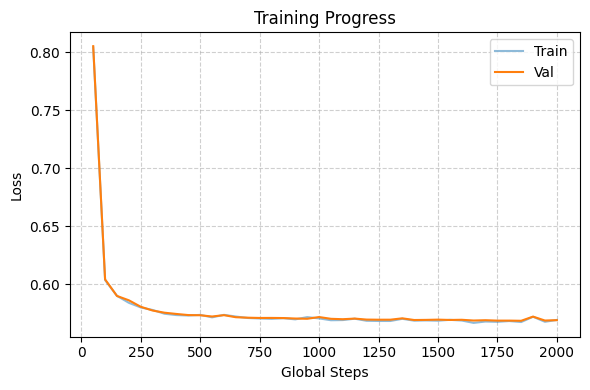

In [ ]:
plot_training_results(train_losses6, val_losses6, 50, title="Training Progress", y_title="Loss")

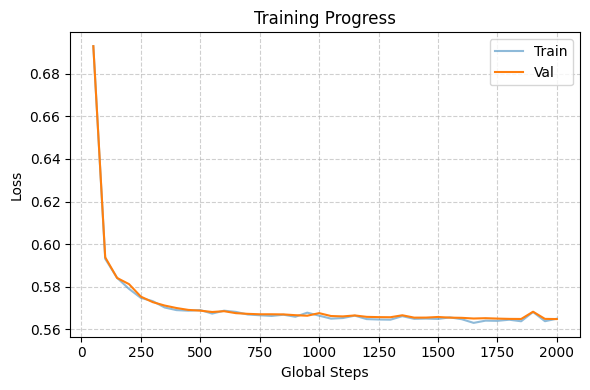

In [ ]:
plot_training_results(train_l1_losses6, val_l1_losses6, 50, title="Training Progress", y_title="Loss")

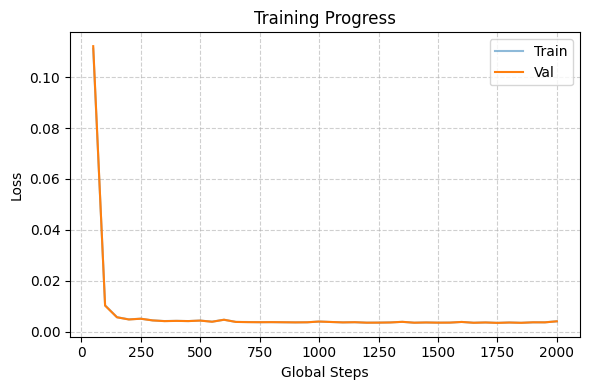

In [ ]:
plot_training_results(train_l3_losses6, val_l3_losses6, 50, title="Training Progress", y_title="Loss")

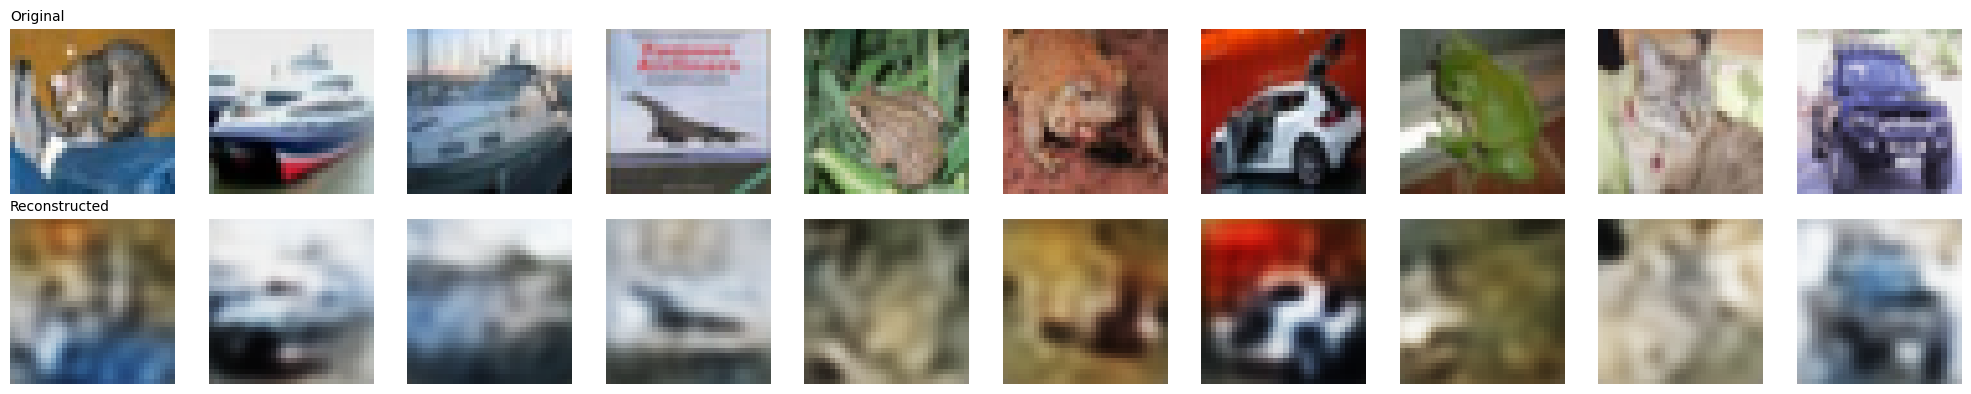

In [ ]:
model = VQVAE2(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512, decay=0.99)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_exp6.pt"))
model.to(device)

plot_generated_vs_original(model, test_loader4, device=device)

In [42]:
model = VQVAE2(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512, decay=0.99)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_exp6.pt"))
model.to(device)

model.eval()
lpips_score = evaluate_lpips(model, test_loader4, device)
rfid_score  = evaluate_rfid(model, test_loader4, device, n_images=5000)

gen_eval["exp_6"] = (lpips_score, rfid_score)

print(f"LPIPS: {lpips_score:.4f}")
print(f"rFID:  {rfid_score:.2f}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
compute FID between two folders
Found 5000 images in the folder /tmp/rfid_eval/real


FID real : 100%|██████████| 157/157 [00:33<00:00,  4.67it/s]


Found 5000 images in the folder /tmp/rfid_eval/recon


FID recon : 100%|██████████| 157/157 [00:32<00:00,  4.89it/s]


LPIPS: 0.1720
rFID:  133.14


#### Exp: 7

In [ ]:
torch.manual_seed(123)
model7 = VQVAE2(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=128, decay=0.99)
model7.to(device)

optimizer7 = torch.optim.Adam(model7.parameters(), lr=0.0001)
epochs = 20
total_steps = epochs * len(train_loader3)
print(f"Total steps: {total_steps}")

global_step7 = -1
train_losses7, val_losses7 = [], []
train_l1_losses7, val_l1_losses7 = [], []
train_l3_losses7, val_l3_losses7 = [], []
train_codebook_usage7, val_codebook_usage7 = [], []

t13 = time.time()

model7.train()
for epoch in range(epochs):
    for x, _ in train_loader3:
        optimizer7.zero_grad()
        loss, _, _, _ = calc_batch_loss2(model7, x, device, training=True)
        loss.backward()
        optimizer7.step()
        global_step7 += 1
        if global_step7 % 500 == 0:
            elapsed = time.time() - t13
            steps_done = global_step7 + 1
            steps_left = total_steps - steps_done
            time_per_step = elapsed / steps_done
            eta_seconds = steps_left * time_per_step
            eta_minutes = eta_seconds / 60
            model7.eval()
            train_loss, train_l1, train_l3, train_cu = evaluate2(train_loader3, model7, device, max_batch=20, k=128)
            val_loss, val_l1, val_l3, val_cu = evaluate2(test_loader3, model7, device, max_batch=None, k=128)
            print(f"Epoch: {epoch:3d} \t\t Step: {global_step7:5d}")
            print(f"\t\t\tTrain Loss: {train_loss:.4f} (l1={train_l1:.4f}, l3={train_l3:.4f}) codebook: {train_cu:.1f}")
            print(f"\t\t\tVal   Loss: {val_loss:.4f} (l1={val_l1:.4f}, l3={val_l3:.4f}) codebook: {val_cu:.1f}")
            print(f"\t\t\tETA: {eta_minutes:.2f} minutes")
            train_losses7.append(train_loss)
            val_losses7.append(val_loss)
            train_l1_losses7.append(train_l1)
            val_l1_losses7.append(val_l1)
            train_l3_losses7.append(train_l3)
            val_l3_losses7.append(val_l3)
            train_codebook_usage7.append(train_cu)
            val_codebook_usage7.append(val_cu)
            reconst = reconstruct2(model7, samples, device)
            fig, axes = plt.subplots(2, 5, figsize=(16, 6))
            for i in range(5):
                axes[0, i].imshow(torch.permute(samples[i], (1, 2, 0)))
                axes[0, i].set_title(f"original {labels[i]}")
                axes[0, i].axis("off")
                axes[1, i].imshow(torch.permute(reconst[i], (1, 2, 0)))
                axes[1, i].set_title(f"reconst {labels[i]}")
                axes[1, i].axis("off")
            plt.tight_layout()
            plt.show()
            model7.train()

t14 = time.time()
print(f"Total training time: {t14-t13:.1f}s")

The code utilization proportion has increased after decreasing the number of codes in codebook, however, there's no improvement in model training.

In [ ]:
torch.save(model7.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae_exp7.pt")

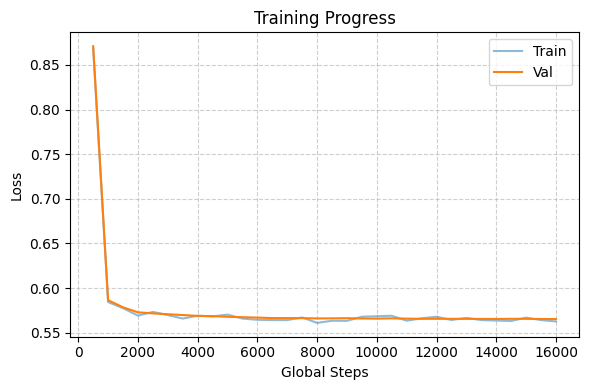

In [ ]:
plot_training_results(train_losses7, val_losses7, 500, title="Training Progress", y_title="Loss")

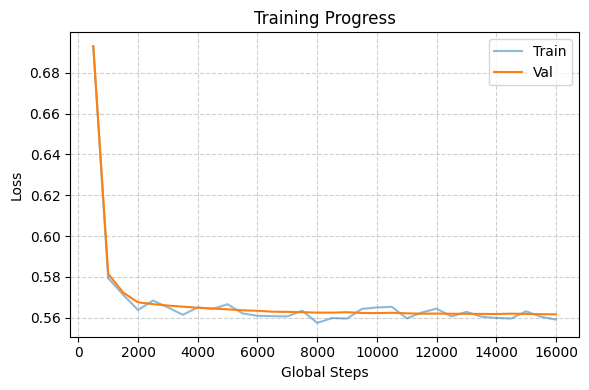

In [ ]:
plot_training_results(train_l1_losses7, val_l1_losses7, 500, title="Training Progress", y_title="Loss")

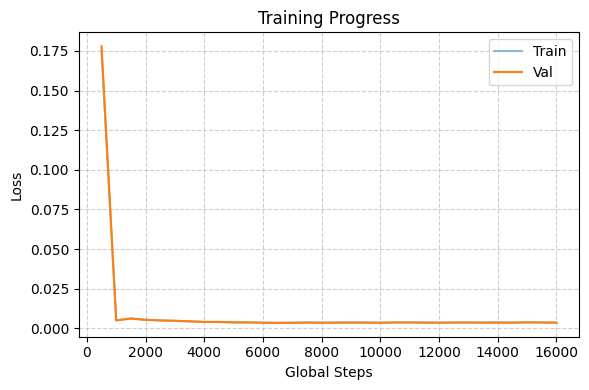

In [ ]:
plot_training_results(train_l3_losses7, val_l3_losses7, 500, title="Training Progress", y_title="Loss")

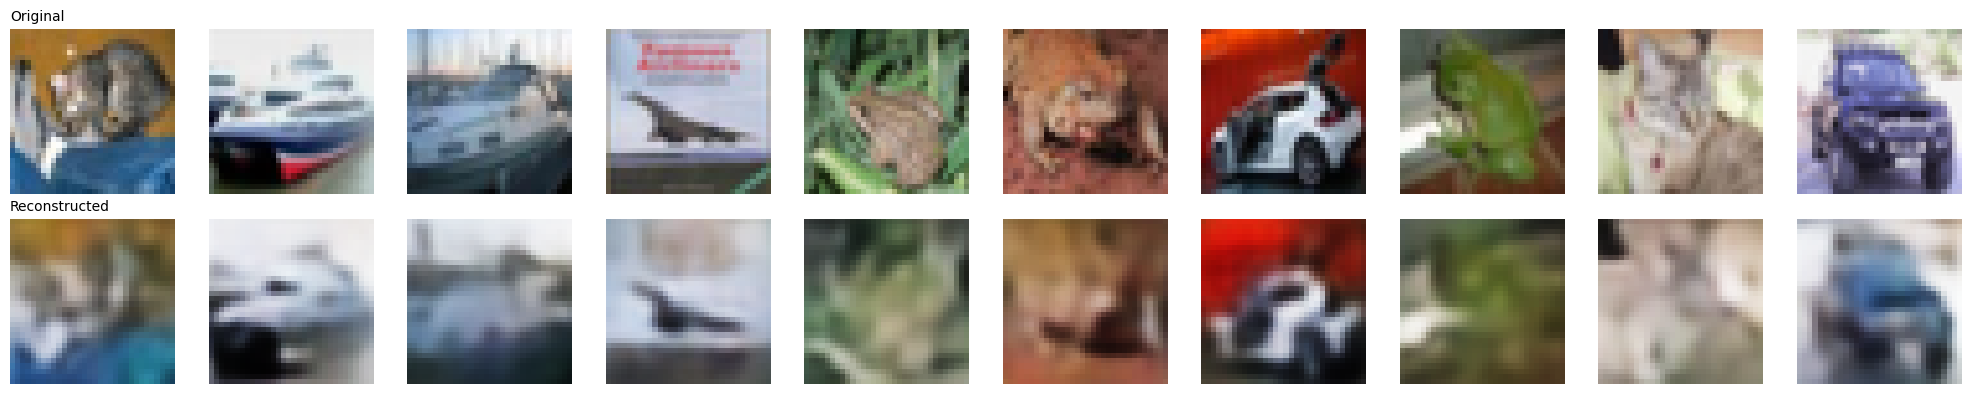

In [ ]:
model = VQVAE2(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=128, decay=0.99)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_exp7.pt"))
model.to(device)

plot_generated_vs_original(model, test_loader3, device=device)

In [43]:
model = VQVAE2(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=128, decay=0.99)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_exp7.pt"))
model.to(device)

model.eval()
lpips_score = evaluate_lpips(model, test_loader3, device)
rfid_score  = evaluate_rfid(model, test_loader3, device, n_images=5000)

gen_eval["exp_7"] = (lpips_score, rfid_score)

print(f"LPIPS: {lpips_score:.4f}")
print(f"rFID:  {rfid_score:.2f}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
compute FID between two folders
Found 5000 images in the folder /tmp/rfid_eval/real


FID real : 100%|██████████| 157/157 [00:34<00:00,  4.58it/s]


Found 5000 images in the folder /tmp/rfid_eval/recon


FID recon : 100%|██████████| 157/157 [00:32<00:00,  4.88it/s]


LPIPS: 0.1134
rFID:  94.97


## Model (EMA Codebook Update + Codebook Restart)

In [44]:
class VQ3(nn.Module):
  def __init__(self, latent_dim, k, decay=0.99):
    super().__init__()
    self.k = k
    self.latent_dim = latent_dim
    self.register_buffer("moving_sum", torch.zeros(k, latent_dim))
    self.register_buffer("moving_count", torch.zeros(k))
    self.register_buffer("codebook", torch.zeros(k, latent_dim))
    self.register_buffer("initialized", torch.tensor(False))
    self.register_buffer("decay", torch.tensor(decay))

  def forward(self, z_e, training):
    B, C, H, W = z_e.shape
    ze_permute = torch.permute(z_e, (0, 2, 3, 1)) # (B, H, W, C)
    if not self.initialized:
      ze_flatten = ze_permute.reshape(-1, C)
      if ze_flatten.shape[0] < self.k:
        indices = torch.randint(0, ze_flatten.shape[0], (self.k,))
        self.codebook.data.copy_(ze_flatten[indices])
        self.initialized.fill_(True)
      else:
        indices = torch.randperm(ze_flatten.shape[0])[:self.k]
        self.codebook.data.copy_(ze_flatten[indices])
        self.initialized.fill_(True)

    # calculating distance as ||z-e||2^2 = z^2 + e^2 - 2*z*e.T
    cross = ze_permute @ self.codebook.T # (B, H, W, k)
    z_l2_sq = (ze_permute ** 2).sum(dim=-1, keepdim=True) # (B, H, W, 1)
    e_l2_sq = (self.codebook ** 2).sum(dim=-1) # (k,)

    discrete_codes = torch.argmin((z_l2_sq + e_l2_sq - 2*cross), dim=-1) # (B, H, W)
    z_q = self.codebook[discrete_codes].permute(0, 3, 1, 2) # (B, C, H, W)

    # EMA codebook update
    if training:
      n_t = torch.zeros(self.k, device=z_e.device)
      codes_flatten = discrete_codes.reshape(-1)
      n_t.scatter_add_(0, codes_flatten, torch.ones(codes_flatten.shape, device=z_e.device))
      self.moving_count.copy_(self.moving_count * self.decay + n_t * (1 - self.decay))
      ze_flatten = ze_permute.reshape(-1, C)
      current_code_sum = torch.zeros_like(self.moving_sum)
      current_code_sum.scatter_add_(0, codes_flatten.unsqueeze(-1).expand(-1, C), ze_flatten)
      self.moving_sum.copy_(self.moving_sum * self.decay + current_code_sum * (1 - self.decay))
      safe_count = self.moving_count.unsqueeze(-1).clamp(min=1e-6)
      self.codebook.data.copy_(self.moving_sum / safe_count)

      # codebook restart for dead entries
      dead = self.moving_count < 1.0
      n_dead = dead.sum().item()
      if n_dead > 0:
        ze_flatten_detached = ze_flatten.detach()
        random_indices = torch.randperm(ze_flatten_detached.shape[0], device=z_e.device)[:n_dead]
        random_ze = ze_flatten_detached[random_indices]
        self.codebook.data[dead] = random_ze
        self.moving_count.data[dead] = 1.0
        self.moving_sum.data[dead] = random_ze

    return z_q, discrete_codes

In [45]:
class ResidualBlock3(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 1),
        )

    def forward(self, x):
        return x + self.block(x)

class Encoder3(nn.Module):
    def __init__(self, in_channels, hidden, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden, 4, stride=2, padding=1),
            nn.Conv2d(hidden, hidden, 4, stride=2, padding=1),
            ResidualBlock3(hidden),
            ResidualBlock3(hidden),
            nn.Conv2d(hidden, latent_dim, 1),  # project to codebook dim
        )

    def forward(self, x):
        return self.net(x)

class Decoder3(nn.Module):
    def __init__(self, latent_dim, hidden, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(latent_dim, hidden, 1),  # project back from codebook dim
            ResidualBlock3(hidden),
            ResidualBlock3(hidden),
            nn.ConvTranspose2d(hidden, hidden, 4, stride=2, padding=1),
            nn.ConvTranspose2d(hidden, out_channels, 4, stride=2, padding=1),
        )

    def forward(self, x):
        return self.net(x)

In [46]:
class VQVAE3(nn.Module):
  def __init__(self, in_channels, out_channels, latent_dim, hidden, k, decay=0.99):
    super().__init__()
    self.encoder = Encoder3(in_channels, hidden, latent_dim)
    self.decoder = Decoder3(latent_dim, hidden, out_channels)
    self.vq_layer = VQ3(latent_dim, k, decay=decay)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x, training=False):
    z_e = self.encoder(x)
    z_q, discrete_codes = self.vq_layer(z_e, training)
    decoder_inp = z_e + (z_q - z_e).detach() # straight through estimator, the effective value for the forward pass is z_q only but the gradients flow to z_e
    reconst = self.sigmoid(self.decoder(decoder_inp))

    return reconst, z_e, z_q, discrete_codes

### Training

In [ ]:
def calc_batch_loss3(model, x, device, training, beta=0.25):
  x = x.to(device)
  reconst, z_e, z_q, discrete_codes = model(x, training)
  # l_1 = nn.functional.binary_cross_entropy(reconst, x, reduction="sum")/x.shape[0]
  l_1 = nn.functional.binary_cross_entropy(reconst, x)
  ze_permute = torch.permute(z_e, (0, 2, 3, 1)) # (B, H, W, C)
  zq_permute = torch.permute(z_q, (0, 2, 3, 1)) # (B, H, W, C)
  # l_3 = (beta * torch.norm(ze_permute - zq_permute.detach(), dim=-1) ** 2).sum()/x.shape[0]
  l_3 = (beta * torch.norm(ze_permute - zq_permute.detach(), dim=-1) ** 2).mean()
  loss = l_1 + l_3

  return loss, l_1, l_3, discrete_codes

In [ ]:
def evaluate3(loader, model, device, max_batch, k):
  total_loss = 0
  total_l1_loss, total_l3_loss = 0, 0
  all_codes = []
  if max_batch is None:
    max_batch = len(loader)
  elif max_batch <= 0:
    return float("nan")
  else:
    max_batch = min(max_batch, len(loader))

  for i, (x, _) in enumerate(loader):
    if i < max_batch:
      with torch.no_grad():
        loss, l_1, l_3, discrete_codes = calc_batch_loss3(model, x, device, training=False)
      total_loss += loss.item()
      total_l1_loss += l_1.item()
      total_l3_loss += l_3.item()
      all_codes.append(discrete_codes.reshape(-1))
    else:
      break
  all_codes = torch.cat(all_codes)

  return total_loss/max_batch, total_l1_loss/max_batch, total_l3_loss/max_batch, all_codes.unique().numel() / k

In [ ]:
def reconstruct3(model, x, device):
    model.eval()
    with torch.no_grad():
      x = x.to(device)
      reconst, _, _, _ = model(x, training=False)
    return reconst.cpu()

In [47]:
train_loader5 = DataLoader(cifar_train, batch_size=64, shuffle=True, num_workers=0)
test_loader5 = DataLoader(cifar_test, batch_size=64, shuffle=False, num_workers=0)

In [48]:
len(train_loader5), len(test_loader5)

(782, 157)

#### Exp: 8

Codebook restart upon increased dead codes count.

In [ ]:
torch.manual_seed(123)
model8 = VQVAE3(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512, decay=0.99)
model8.to(device)

optimizer8 = torch.optim.Adam(model8.parameters(), lr=0.0001)
epochs = 20
total_steps = epochs * len(train_loader5)
print(f"Total steps: {total_steps}")

global_step8 = -1
train_losses8, val_losses8 = [], []
train_l1_losses8, val_l1_losses8 = [], []
train_l3_losses8, val_l3_losses8 = [], []
train_codebook_usage8, val_codebook_usage8 = [], []

t15 = time.time()

model8.train()
for epoch in range(epochs):
    for x, _ in train_loader5:
        optimizer8.zero_grad()
        loss, _, _, _ = calc_batch_loss3(model8, x, device, training=True)
        loss.backward()
        optimizer8.step()
        global_step8 += 1
        if global_step8 % 500 == 0:
            elapsed = time.time() - t15
            steps_done = global_step8 + 1
            steps_left = total_steps - steps_done
            time_per_step = elapsed / steps_done
            eta_seconds = steps_left * time_per_step
            eta_minutes = eta_seconds / 60
            model8.eval()
            train_loss, train_l1, train_l3, train_cu = evaluate3(train_loader5, model8, device, max_batch=20, k=512)
            val_loss, val_l1, val_l3, val_cu = evaluate3(test_loader5, model8, device, max_batch=None, k=512)
            print(f"Epoch: {epoch:3d} \t\t Step: {global_step8:5d}")
            print(f"\t\t\tTrain Loss: {train_loss:.4f} (l1={train_l1:.4f}, l3={train_l3:.4f}) codebook: {train_cu:.1f}")
            print(f"\t\t\tVal   Loss: {val_loss:.4f} (l1={val_l1:.4f}, l3={val_l3:.4f}) codebook: {val_cu:.1f}")
            print(f"\t\t\tETA: {eta_minutes:.2f} minutes")
            train_losses8.append(train_loss)
            val_losses8.append(val_loss)
            train_l1_losses8.append(train_l1)
            val_l1_losses8.append(val_l1)
            train_l3_losses8.append(train_l3)
            val_l3_losses8.append(val_l3)
            train_codebook_usage8.append(train_cu)
            val_codebook_usage8.append(val_cu)
            reconst = reconstruct3(model8, samples, device)
            fig, axes = plt.subplots(2, 5, figsize=(16, 6))
            for i in range(5):
                axes[0, i].imshow(torch.permute(samples[i], (1, 2, 0)))
                axes[0, i].set_title(f"original {labels[i]}")
                axes[0, i].axis("off")
                axes[1, i].imshow(torch.permute(reconst[i], (1, 2, 0)))
                axes[1, i].set_title(f"reconst {labels[i]}")
                axes[1, i].axis("off")
            plt.tight_layout()
            plt.show()
            model8.train()

t16 = time.time()
print(f"Total training time: {t16-t15:.1f}s")

In [ ]:
torch.save(model8.state_dict(), "/content/drive/My Drive/GenAI/Data/vqvae_exp8.pt")

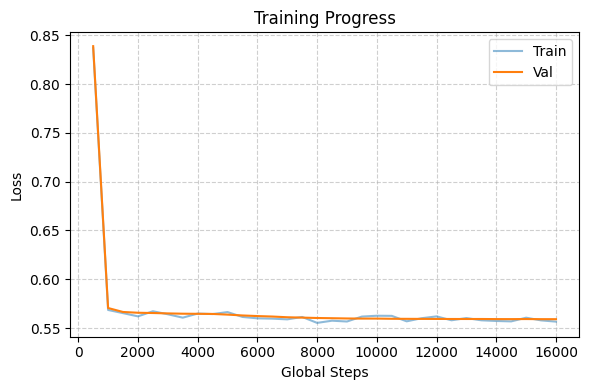

In [ ]:
plot_training_results(train_losses8, val_losses8, 500, title="Training Progress", y_title="Loss")

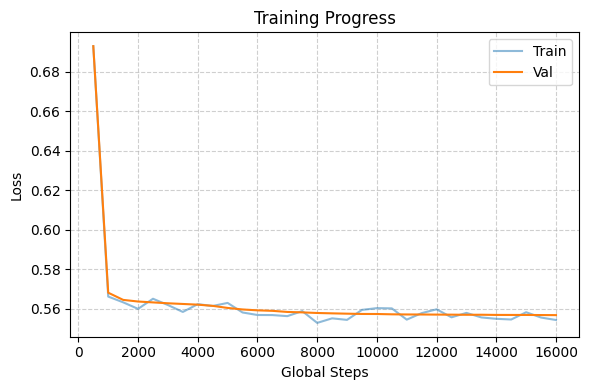

In [ ]:
plot_training_results(train_l1_losses8, val_l1_losses8, 500, title="Training Progress", y_title="Loss")

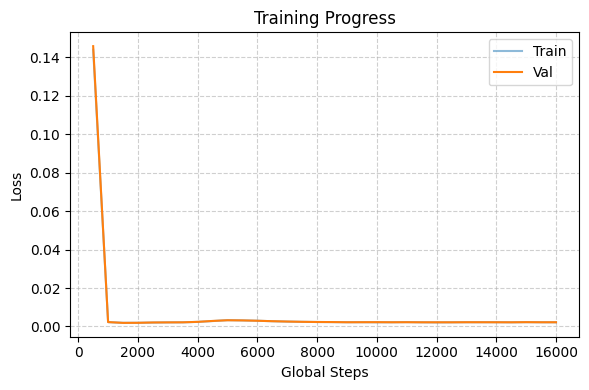

In [ ]:
plot_training_results(train_l3_losses8, val_l3_losses8, 500, title="Training Progress", y_title="Loss")

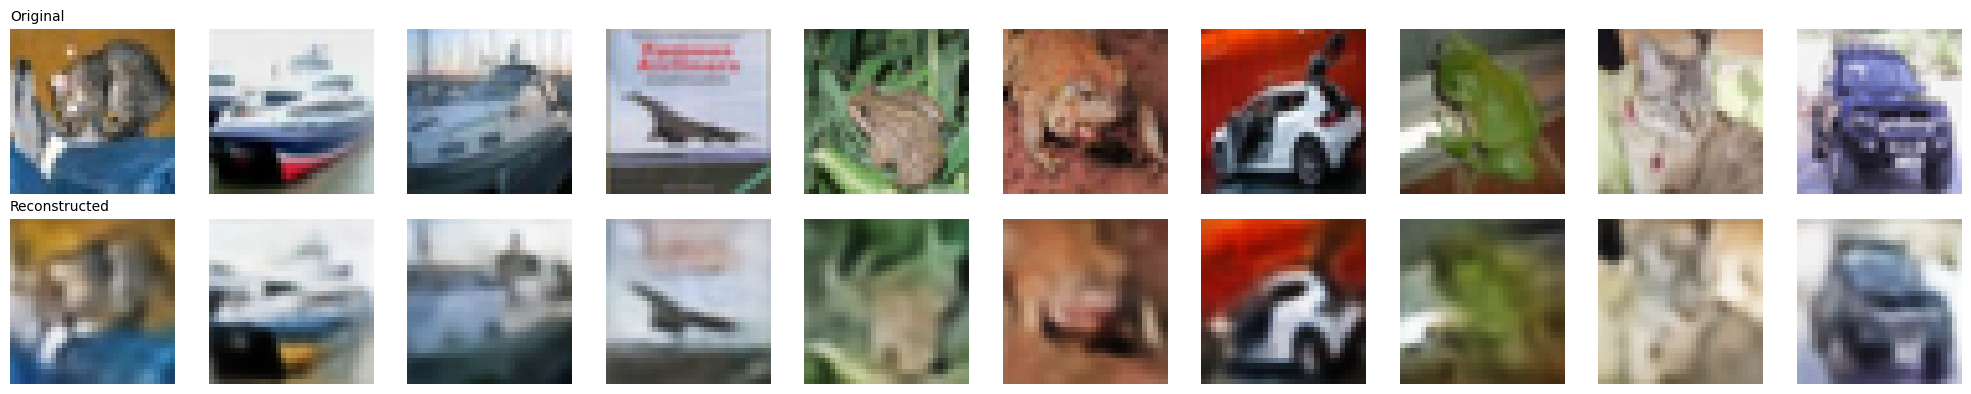

In [ ]:
model = VQVAE3(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512, decay=0.99)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_exp8.pt"))
model.to(device)

plot_generated_vs_original(model, test_loader5, device=device)

In [49]:
model = VQVAE3(in_channels=3, out_channels=3, latent_dim=256, hidden=256, k=512, decay=0.99)
model.load_state_dict(torch.load("/content/drive/My Drive/GenAI/Data/vqvae_exp8.pt"))
model.to(device)

model.eval()
lpips_score = evaluate_lpips(model, test_loader5, device)
rfid_score  = evaluate_rfid(model, test_loader5, device, n_images=5000)

gen_eval["exp_8"] = (lpips_score, rfid_score)

print(f"LPIPS: {lpips_score:.4f}")
print(f"rFID:  {rfid_score:.2f}")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
compute FID between two folders
Found 5000 images in the folder /tmp/rfid_eval/real


FID real : 100%|██████████| 157/157 [00:33<00:00,  4.75it/s]


Found 5000 images in the folder /tmp/rfid_eval/recon


FID recon : 100%|██████████| 157/157 [00:32<00:00,  4.84it/s]


LPIPS: 0.0617
rFID:  79.59


To Dos (Future work):
- try beta=0.1 or lower (this will allow encoder output to be updated more towards improving reconstruction rather than being close to the assigned discrete code)
- try layernorm on encoder's output
- try on imagenet

## Generation Quality Comparison

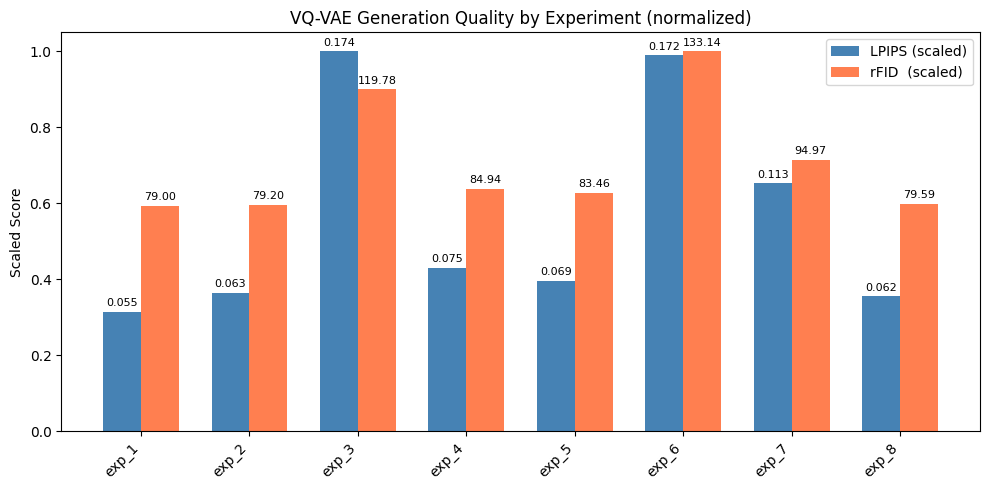

In [56]:
plot_gen_eval(gen_eval)